# Matplotlib Complete Guide
## A Comprehensive Tutorial from Basics to Advanced

This notebook combines the best elements from three excellent matplotlib resources:
- **Kopie_von_Intro_to_matplotlib.ipynb** - Comprehensive reference material
- **matplotlib_fundamentals_explained.ipynb** - Excellent conceptual explanations
- **introduction-to-matplotlib-video.ipynb** - Practical, hands-on examples

**Total Duration:** Approximately 4-5 hours (with exercises)

**Prerequisites:**
- Basic Python knowledge
- Familiarity with Jupyter notebooks
- NumPy basics (helpful but not required)

**Learning Objectives:**
By the end of this notebook, you will be able to:
1. Understand matplotlib's architecture (Figure, Axes, pyplot vs OO interface)
2. Create various plot types (line, scatter, bar, histogram)
3. Work with both NumPy arrays and Pandas DataFrames
4. Customize plots professionally (colors, styles, labels, legends)
5. Create complex multi-panel figures
6. Export publication-quality figures
7. Apply best practices for data visualization

---


## Table of Contents

1. **Introduction & Setup** (15-20 min)
2. **Core Concepts - Figure Architecture** (20-25 min)
3. **Understanding Data for Plotting** (15-20 min)
4. **Basic Plot Types with NumPy** (30-35 min)
5. **Plotting with Pandas DataFrames** (25-30 min)
6. **Subplots and Multi-Panel Figures** (25-30 min)
7. **Customization Fundamentals** (30-35 min)
8. **Advanced Customization** (25-30 min)
9. **Special Plot Types and Scales** (20-25 min)
10. **Figure Configuration and Export** (15-20 min)
11. **Practical Integration & Best Practices** (20-25 min)
12. **Self-Assessment & Next Steps** (10-15 min)

---


---

# Section 1: Introduction & Setup

**Description:** What is matplotlib, installation, imports, and your first plot

**Estimated Time:** 15-20 minutes

---


### From kopie
*Introduction and basic setup*


# Plotting in Python with matplotlib
Marco Chierici & Giuseppe Jurman

Apr 26, 2023

# Common Jupyter notebook shortcuts

- Create an empty code cell above the selected cell: ESC + A
- Create an empty code cell below the selected cell: ESC + B
- Change selected cell type from code to text (markdown): ESC + M
- Change selected cell type from text to code: ESC + Y
- Delete selected cell: ESC + DD (not a typo: two times D)
- Copy selected cell: ESC + C
- Paste selected cell below: ESC + V
- Execute current cell: SHIFT + ENTER

# Kick off

To load matplotlib, we use the following import convention:

In [74]:
import matplotlib
import matplotlib.pyplot as plt

Since we are in a Jupyter notebook, we also execute the following statement to output plots directly in the Jupyter notebook:

In [75]:
%matplotlib inline

We also load the Python numerical library (NumPy: Numerical Python) and Pandas with their import convention:

In [76]:
import numpy as np
import pandas as pd

# Intro

Matplotlib is an excellent 2D and 3D graphics library for generating scientific figures. Some of the many advantages of this library include:

* Easy to get started
* Support for $\LaTeX$ formatted labels and texts
* Great control of every element in a figure, including figure size and DPI.
* High-quality output in many formats, including PNG, PDF, SVG, EPS, and PGF.
* GUI for interactively exploring figures *and* support for headless generation of figure files (useful for batch jobs).

One of the key features of matplotlib that I would like to emphasize, and that I think makes matplotlib highly suitable for generating figures for scientific publications is that all aspects of the figure can be controlled *programmatically*. This is important for reproducibility and convenient when one needs to regenerate the figure with updated data or change its appearance.

More information at the Matplotlib web page: http://matplotlib.org/



### From video
*Matplotlib concepts and why use it*


# Introduction to Matplotlib

This notebook is the practical entry point into Matplotlib, but with a stronger conceptual bridge between the examples.

It combines the quick-start feel of this video notebook with selected ideas from `Kopie_von_Intro_to_matplotlib.ipynb` and `matplotlib_fundamentals_explained.ipynb`.

## What you will learn

1. The two main ways of creating plots: `pyplot` and the object-oriented (OO) interface
2. How to go from an empty `plt.plot()` call to plotting real x/y data
3. Why `fig, ax = plt.subplots()` is the default pattern we keep coming back to
4. How `np.linspace()` helps create smooth lines and well-spaced axes
5. The most common plot types with NumPy arrays and pandas data
6. How to customize labels, legends, ticks, limits, styles, and colors
7. How to save plots and where to go next afterwards

A short roadmap to the follow-up notebooks is included at the end.


## 0. Concepts in Matplotlib

Matplotlib is one of the core plotting libraries in the Python data ecosystem. It gives you fine-grained control over almost every visual part of a plot, which is why it is used so often in data science, research, and reporting.

### Why Matplotlib?

- It works well with Python lists, NumPy arrays, pandas Series, and DataFrames
- It scales from very quick experiments to publication-style figures
- It teaches you the plotting vocabulary used by many other libraries
- It is especially strong when you want explicit control over the figure

### A simple workflow to keep in mind

1. Import plotting tools
2. Prepare data
3. Create a figure and one or more axes
4. Plot the data
5. Customize labels, legends, limits, and styling
6. Show or save the figure


## 1. Two ways of creating plots

Matplotlib gives us two closely related interfaces:

- `pyplot`: quick, state-based, great for getting started fast
- `OO` (object-oriented): explicit and more robust, especially when plots become more complex

We will start with `pyplot` because it makes the first examples very easy to read. Then we will switch to `fig, ax = plt.subplots()` and use that pattern as our default.

Start by importing `matplotlib.pyplot` and enabling inline output in the notebook.


---

# Section 2: Core Concepts - Figure Architecture

**Description:** Understanding Figure vs Axes hierarchy, pyplot vs OO interface

**Estimated Time:** 20-25 minutes

---


### From kopie
*Figures, subplots, and axes hierarchy*


## Two interfaces at the price of one

### MATLAB-like

At the top of the matplotlib hierarchy is the "state-machine environment" which is provided by the `matplotlib.pyplot` module. This is also called the **MATLAB-like interface**.

In the examples above, we used this kind of interface. At this level, most of the plotting related elements (lines, images, text, etc.) are handled by the `pyplot` module.

This interface is usually the easiest way to get started with plotting using matplotlib. It is designed to be compatible with [MATLAB](https://it.mathworks.com/products/matlab.html)'s plotting functions, so it is easier to get started with if you are familiar with MATLAB.

It also has a minumum of coding overhead for simple plots.

### Object-oriented

The next level down in the matplotlib hierarchy is the object-oriented (OO) interface.

The main idea with OO programming is to have objects that one can apply functions and actions on, and no object or program states should be global (such as the MATLAB-like interface). The real advantage of this approach becomes apparent when more than one figure is created, or when a figure contains more than one subplot - more about that later.

At this level, the user creates figures with `pyplot`, and through those figures, one or more "axes" objects can be created. These axes objects are then used for most plotting actions.

## Figures and subplots

Everything in matplotlib lives within a `Figure` object.

The figure keeps track of all the child Axes, a group of special "Artists" (titles, figure legends, etc), nested subfigures, and the canvas.

A figure can have any number of Axes (at least one, to be useful).

You can think of the figure object as a canvas that holds all the subplots and other plot elements inside it.

## Parts of a figure
![](https://matplotlib.org/stable/_images/anatomy.png)

The easiest way to create a new figure is with `plt.figure`:

In [88]:
fig = plt.figure()  # an empty figure with no axes

<Figure size 640x480 with 0 Axes>

In [89]:
plt.show()

We use now the OO interface: instead of creating a new global figure instance we store a reference to the newly created figure instance in the `fig` variable, and from it we create a new axis instance using the `add_axes` method:

In [90]:
axes = fig.add_axes([0.1, 0.1, 0.8, 0.8]) # left, bottom, width, height (range 0-1)

Then, we add a plot to the `axes` object, and customize x-y axis labels and plot title:

In [91]:
axes.plot(x, y, 'r')
axes.set_xlabel('x')
axes.set_ylabel('y')
axes.set_title('Quadratic function')

Text(0.5, 1.0, 'Quadratic function')

Unfortunately, inside Jupter notebooks the plots are reset after evaluating each cell, so we have to put all of the above commands in the same cell to see the result!

Text(0.5, 1.0, 'Quadratic function')

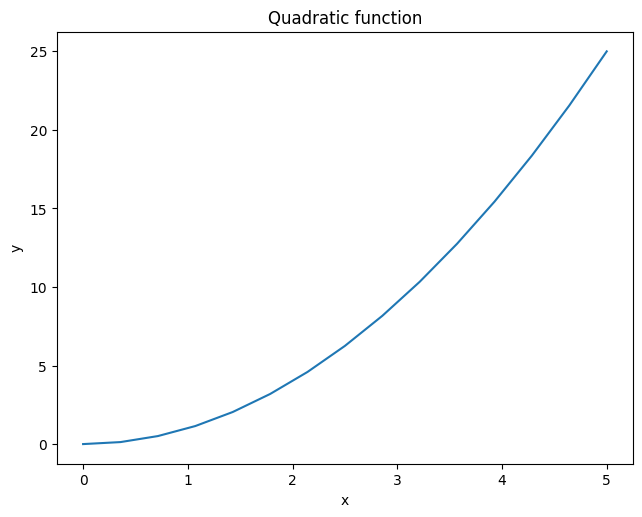

In [92]:
fig = plt.figure()  # an empty figure with no axes
axes = fig.add_axes([0.1, 0.1, 0.9, 0.9]) # left, bottom, width, height (range 0-1)

axes.plot(x, y)
axes.set_xlabel('x')
axes.set_ylabel('y')
axes.set_title('Quadratic function')

Although a little bit more code is involved, the advantage is that we now have full control of where the plot axes are placed, and we can easily add more than one axis to the figure:

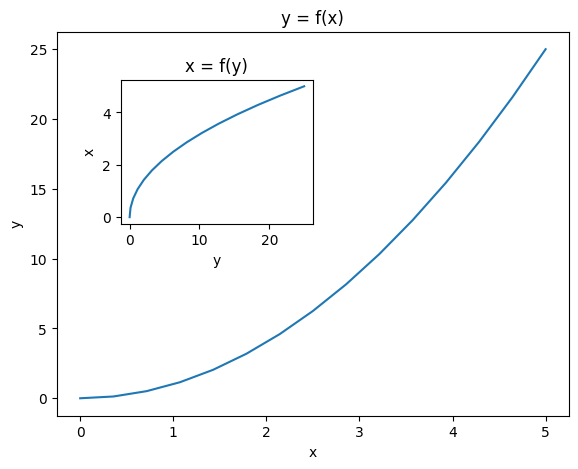

In [93]:
fig = plt.figure()

axes1 = fig.add_axes([0.1, 0.1, 0.8, 0.8]) # main axes
axes2 = fig.add_axes([0.2, 0.5, 0.3, 0.3]) # inset axes

# main figure
axes1.plot(x, y)
axes1.set_xlabel('x')
axes1.set_ylabel('y')
axes1.set_title('y = f(x)')

# inset
axes2.plot(y, x)
axes2.set_xlabel('y')
axes2.set_ylabel('x')
axes2.set_title('x = f(y)');

If we don't care about specifying where the plot axes are placed in the figure canvas, then we can use one of the many axis layout managers in matplotlib. My favorite is `subplots`, which can be used like this:

Text(0.5, 0.98, 'Figure title')

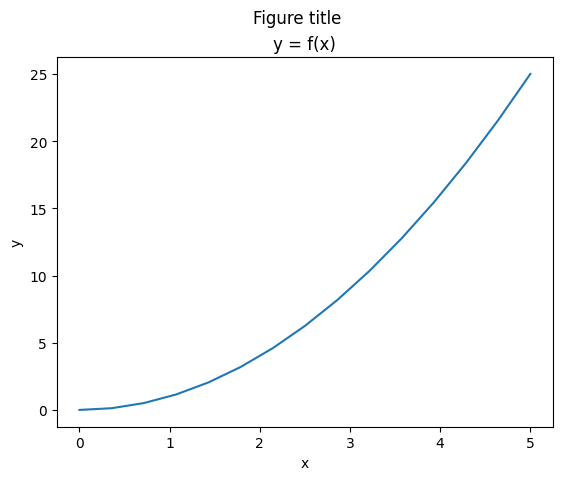

In [94]:
fig, ax = plt.subplots()

ax.plot(x, y)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('y = f(x)') # this is the axis title
fig.suptitle("Figure title") # this is the figure title

Alternatively, we can create one or more subplots with `add_subplot(nrows, ncols, subplot_id)`: more on this later.

Text(0.5, 1.0, 'x = f(y)')

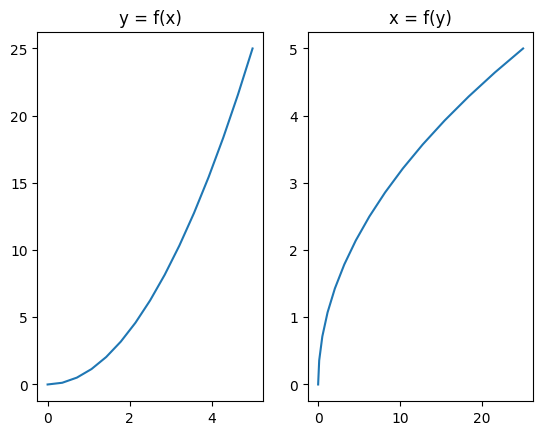

In [95]:
fig = plt.figure()
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

ax1.plot(x, y)
ax1.set_title("y = f(x)")

ax2.plot(y, x)
ax2.set_title("x = f(y)")

### From fundamentals
*plt.show() vs fig.show() and architecture*


<!-- Translation needed from German -->

## ⚠️ WICHTIG: `plt.show()` vs. `fig.show()` - Was ist der Unterschied?

### Die Verwirrung:

Wenn du mit Matplotlib arbeitest, siehst du oft zwei verschiedene Methoden, um Plots anzuzeigen:

```python
# Methode 1
fig, ax = plt.subplots()
ax.plot([1, 2, 3], [1, 2, 3])
plt.show()  # ← Modul-Funktion

# Methode 2
fig, ax = plt.subplots()
ax.plot([1, 2, 3], [1, 2, 3])
fig.show()  # ← Objekt-Methode
```

### Warum `plt.show()` und NICHT `fig.show()`?

#### 1. **`plt.show()` ist die offizielle, empfohlene Methode**

- `plt` ist das **pyplot Modul** von Matplotlib
- `plt.show()` ist eine **Modul-Funktion**, die alle offenen Figures verwaltet
- Sie ist speziell für interaktive Umgebungen (wie Jupyter) optimiert

#### 2. **`fig.show()` ist eine Objekt-Methode mit Einschränkungen**

- `fig` ist ein **Figure-Objekt**
- `fig.show()` ist eine **Objekt-Methode**, die nur diese eine Figure betrifft
- Sie verhält sich in Jupyter Notebooks anders als erwartet
- Sie kann zu Problemen mit dem Figure-Management führen

### Was passiert technisch?

```python
# plt.show() macht:
# 1. Zeigt ALLE offenen Figures an
# 2. Wartet auf Benutzerinteraktion (in interaktiven Backends)
# 3. Schließt die Figures nach dem Anzeigen
# 4. Gibt Speicher frei

# fig.show() macht:
# 1. Zeigt NUR diese eine Figure an
# 2. Schließt die Figure NICHT automatisch
# 3. Figure bleibt im Speicher
# 4. Kann zu Memory-Leaks führen
```

### Praktischer Vergleich:

| Aspekt | `plt.show()` | `fig.show()` |
|--------|-------------|-------------|
| **Empfohlen?** | ✅ Ja | ❌ Nein |
| **Jupyter Notebooks** | ✅ Funktioniert perfekt | ⚠️ Kann Probleme machen |
| **Speicherverwaltung** | ✅ Automatisch | ❌ Manuell nötig |
| **Mehrere Figures** | ✅ Zeigt alle | ❌ Nur eine |
| **Schließt Figure** | ✅ Ja | ❌ Nein |

### Die Regel:

```python
# ✅ IMMER SO:
fig, ax = plt.subplots()
ax.plot(x, y)
plt.show()  # Nutze plt.show()

# ❌ NICHT SO:
fig, ax = plt.subplots()
ax.plot(x, y)
fig.show()  # Vermeide fig.show()

# ✅ ODER IN JUPYTER (automatische Anzeige):
fig, ax = plt.subplots()
ax.plot(x, y)
# Kein show() nötig - wird automatisch angezeigt
```

### Warum ist das wichtig?

1. **Konsistenz**: Dein Code funktioniert überall gleich
2. **Keine Memory-Leaks**: Figures werden ordentlich geschlossen
3. **Best Practice**: Folgt den offiziellen Matplotlib-Empfehlungen
4. **Weniger Bugs**: Vermeidet subtile Probleme mit Figure-Management

---

**💡 Merke dir:** Nutze immer `plt.show()`, nie `fig.show()`!

In [6]:
y_axis

[1400, 1500]

<!-- Translation needed from German -->

## 2. Figure und Axes - Die Matplotlib Architektur

### Die Hierarchie:

```
Figure (die gesamte Zeichenfläche)
  └── Axes (der Plotbereich mit x/y-Achsen)
       ├── x-Achse
       ├── y-Achse
       └── Plot-Elemente (Linien, Punkte, etc.)
```

### Wichtig zu verstehen:

- **Figure** = Das gesamte Fenster/Bild (wie ein Blatt Papier)
- **Axes** = Der eigentliche Plot-Bereich (wie ein Koordinatensystem auf dem Papier)
- Eine Figure kann mehrere Axes enthalten (Subplots)
- Axes ist NICHT die Achse (axis), sondern der gesamte Plot-Bereich!

<!-- Translation needed from German -->

## 3. Wie werden die Achsen (Axes) automatisch erstellt?

### Die Frage:
Woher weiß Matplotlib, welche Werte auf den Achsen angezeigt werden sollen?

### Die Antwort:
Matplotlib analysiert automatisch die Daten und setzt die Achsengrenzen basierend auf:
1. **Minimum der Daten** (mit etwas Puffer)
2. **Maximum der Daten** (mit etwas Puffer)

### Schauen wir uns das genau an:

---

# Section 3: Understanding Data for Plotting

**Description:** NumPy arrays, lists, linspace, and why arrays matter

**Estimated Time:** 15-20 minutes

---


### From fundamentals
*np.linspace() explanation*


<!-- Translation needed from German -->

## 1. `np.linspace()` - Gleichmäßig verteilte Punkte

### Was macht `linspace()`?

`np.linspace(start, stop, num)` erstellt ein Array mit `num` gleichmäßig verteilten Werten zwischen `start` und `stop`.

### Warum brauchen wir das?

Für glatte Kurven brauchen wir viele Datenpunkte. Statt sie manuell zu schreiben, generiert `linspace()` sie automatisch.

### From fundamentals
*Arrays vs lists and performance*


<!-- Translation needed from German -->

## 4. Arrays vs. Listen - Warum kein einfaches "Mapping"?

### Die Frage:
Warum kann man ein NumPy Array nicht einfach wie eine Python-Liste mit `map()` bearbeiten?

### Die Antwort:
NumPy Arrays sind **fundamental anders** als Python-Listen:

1. **Arrays sind homogen** (alle Elemente gleicher Typ)
2. **Arrays sind optimiert** für numerische Operationen
3. **Arrays unterstützen Vektorisierung** (Operationen auf allen Elementen gleichzeitig)

### Schauen wir uns die Unterschiede an:

In [16]:
# Python Liste
python_liste = [1, 2, 3, 4, 5]
print("Python Liste:")
print(f"Typ: {type(python_liste)}")
print(f"Inhalt: {python_liste}")

# NumPy Array
numpy_array = np.array([1, 2, 3, 4, 5])
print("\nNumPy Array:")
print(f"Typ: {type(numpy_array)}")
print(f"Inhalt: {numpy_array}")
print(f"Datentyp der Elemente: {numpy_array.dtype}")
print(f"Shape: {numpy_array.shape}")

Python Liste:
Typ: <class 'list'>
Inhalt: [1, 2, 3, 4, 5]

NumPy Array:
Typ: <class 'numpy.ndarray'>
Inhalt: [1 2 3 4 5]
Datentyp der Elemente: int64
Shape: (5,)


### Unterschied 1: Operationen auf allen Elementen

In [17]:
# Mit Python Liste - braucht map() oder List Comprehension
python_liste = [1, 2, 3, 4, 5]

# Methode 1: List Comprehension
verdoppelt_liste = [x * 2 for x in python_liste]
print("Python Liste verdoppelt (List Comprehension):")
print(verdoppelt_liste)

# Methode 2: map()
verdoppelt_map = list(map(lambda x: x * 2, python_liste))
print("\nPython Liste verdoppelt (map):")
print(verdoppelt_map)

print("\n" + "="*60)

# Mit NumPy Array - direkte Operation!
numpy_array = np.array([1, 2, 3, 4, 5])
verdoppelt_array = numpy_array * 2  # ✨ Vektorisierte Operation!
print("\nNumPy Array verdoppelt (direkt):")
print(verdoppelt_array)

print("\n💡 NumPy Arrays unterstützen direkte Operationen auf allen Elementen!")
print("   Das nennt man 'Vektorisierung' - viel schneller als map()!")

Python Liste verdoppelt (List Comprehension):
[2, 4, 6, 8, 10]

Python Liste verdoppelt (map):
[2, 4, 6, 8, 10]


NumPy Array verdoppelt (direkt):
[ 2  4  6  8 10]

💡 NumPy Arrays unterstützen direkte Operationen auf allen Elementen!
   Das nennt man 'Vektorisierung' - viel schneller als map()!


### Unterschied 2: Mathematische Operationen

In [18]:
# Python Liste - funktioniert NICHT direkt
python_liste = [1, 2, 3, 4, 5]

print("❌ Python Liste * 2 funktioniert nicht wie erwartet!")
print(f"   Ergebnis: {python_liste * 2}")
print("   (Liste wird wiederholt, nicht multipliziert!)")

print("\n" + "="*60 + "\n")

# NumPy Array - funktioniert perfekt!
numpy_array = np.array([1, 2, 3, 4, 5])
print("✅ NumPy Array * 2:")
print(numpy_array * 2)

print("\n✅ NumPy Array + 10:")
print(numpy_array + 10)

print("\n✅ NumPy Array ** 2 (Quadrat):")
print(numpy_array ** 2)

print("\n✅ NumPy Array / 2:")
print(numpy_array / 2)

❌ Python Liste * 2 funktioniert nicht wie erwartet!
   Ergebnis: [1, 2, 3, 4, 5, 1, 2, 3, 4, 5]
   (Liste wird wiederholt, nicht multipliziert!)


✅ NumPy Array * 2:
[ 2  4  6  8 10]

✅ NumPy Array + 10:
[11 12 13 14 15]

✅ NumPy Array ** 2 (Quadrat):
[ 1  4  9 16 25]

✅ NumPy Array / 2:
[0.5 1.  1.5 2.  2.5]


### Unterschied 3: Mathematische Funktionen

In [19]:
# NumPy bietet viele mathematische Funktionen
x = np.array([0, 1, 2, 3, 4, 5])

print("Original Array:")
print(x)

print("\nMathematische Funktionen:")
print(f"Quadratwurzel: {np.sqrt(x)}")
print(f"Exponential: {np.exp(x)}")
print(f"Logarithmus: {np.log(x[1:])}  # (ohne 0, da log(0) undefiniert)")
print(f"Sinus: {np.sin(x)}")

print("\n💡 Diese Funktionen arbeiten auf dem gesamten Array gleichzeitig!")
print("   Mit Python-Listen bräuchtest du map() oder eine Schleife.")

Original Array:
[0 1 2 3 4 5]

Mathematische Funktionen:
Quadratwurzel: [0.         1.         1.41421356 1.73205081 2.         2.23606798]
Exponential: [  1.           2.71828183   7.3890561   20.08553692  54.59815003
 148.4131591 ]
Logarithmus: [0.         0.69314718 1.09861229 1.38629436 1.60943791]  # (ohne 0, da log(0) undefiniert)
Sinus: [ 0.          0.84147098  0.90929743  0.14112001 -0.7568025  -0.95892427]

💡 Diese Funktionen arbeiten auf dem gesamten Array gleichzeitig!
   Mit Python-Listen bräuchtest du map() oder eine Schleife.


Performance-Vergleich (1,000,000 Elemente):

Python Liste (List Comprehension): 0.0159 Sekunden
NumPy Array (Vektorisierung):      0.0006 Sekunden

🚀 NumPy ist 24.5x schneller!


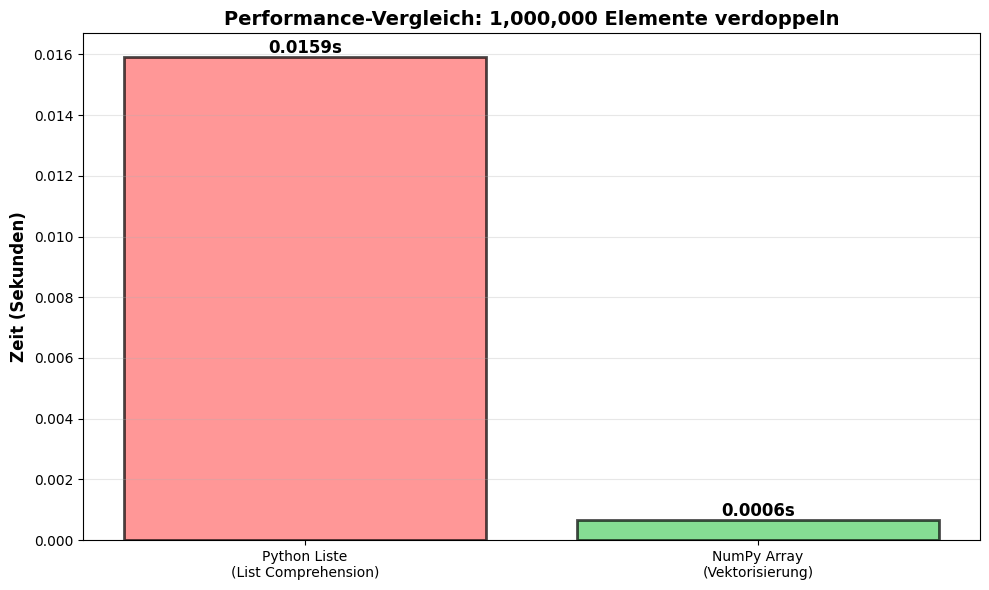

In [20]:
import time

# Große Datenmenge
size = 1000000
python_liste = list(range(size))
numpy_array = np.arange(size)

# Test 1: Python Liste mit List Comprehension
start = time.time()
result_liste = [x * 2 for x in python_liste]
zeit_liste = time.time() - start

# Test 2: NumPy Array mit Vektorisierung
start = time.time()
result_array = numpy_array * 2
zeit_array = time.time() - start

print(f"Performance-Vergleich ({size:,} Elemente):")
print(f"\nPython Liste (List Comprehension): {zeit_liste:.4f} Sekunden")
print(f"NumPy Array (Vektorisierung):      {zeit_array:.4f} Sekunden")
print(f"\n🚀 NumPy ist {zeit_liste/zeit_array:.1f}x schneller!")

# Visualisierung
fig, ax = plt.subplots(figsize=(10, 6))
methoden = ['Python Liste\n(List Comprehension)', 'NumPy Array\n(Vektorisierung)']
zeiten = [zeit_liste, zeit_array]
colors = ['#ff6b6b', '#51cf66']

bars = ax.bar(methoden, zeiten, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Zeit (Sekunden)', fontsize=12, weight='bold')
ax.set_title(f'Performance-Vergleich: {size:,} Elemente verdoppeln', 
             fontsize=14, weight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Werte auf den Balken
for bar, zeit in zip(bars, zeiten):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{zeit:.4f}s',
            ha='center', va='bottom', fontsize=12, weight='bold')

plt.tight_layout()
plt.show()

<!-- Translation needed from German -->

## Zusammenfassung: Warum NumPy Arrays?

### Vorteile von NumPy Arrays:

1. **Vektorisierung**: Operationen auf allen Elementen gleichzeitig
2. **Performance**: Viel schneller als Python-Listen
3. **Mathematische Funktionen**: Eingebaute Funktionen für wissenschaftliches Rechnen
4. **Speichereffizienz**: Kompaktere Speicherung
5. **Broadcasting**: Intelligente Operationen zwischen Arrays verschiedener Größen

### Wann welche Methode?

```python
# ✅ NumPy Array - Für numerische Daten und Berechnungen
x = np.array([1, 2, 3, 4, 5])
y = x * 2  # Direkte Operation

# ✅ Python Liste - Für gemischte Datentypen oder nicht-numerische Daten
mixed = [1, "text", 3.14, True]
processed = [process(item) for item in mixed]  # List Comprehension

# ❌ NICHT empfohlen - map() auf NumPy Arrays
# Nutze stattdessen Vektorisierung!
```

## Praktisches Beispiel: Unsere Wachstumskurve

Jetzt verstehen wir, warum wir in unserem Intensity Chart so vorgehen:

X-Werte (erste 10):
[31.         31.01515152 31.03030303 31.04545455 31.06060606 31.07575758
 31.09090909 31.10606061 31.12121212 31.13636364]

Y-Werte (erste 10):
[50.         52.94030299 55.70769835 58.3123541  60.7638403  63.07116425
 65.24280358 67.28673735 69.21047544 71.02108606]

Automatische Achsengrenzen:
X-Achse: (30.925, 32.575)
Y-Achse: (47.506196880441664, 102.36986551072502)


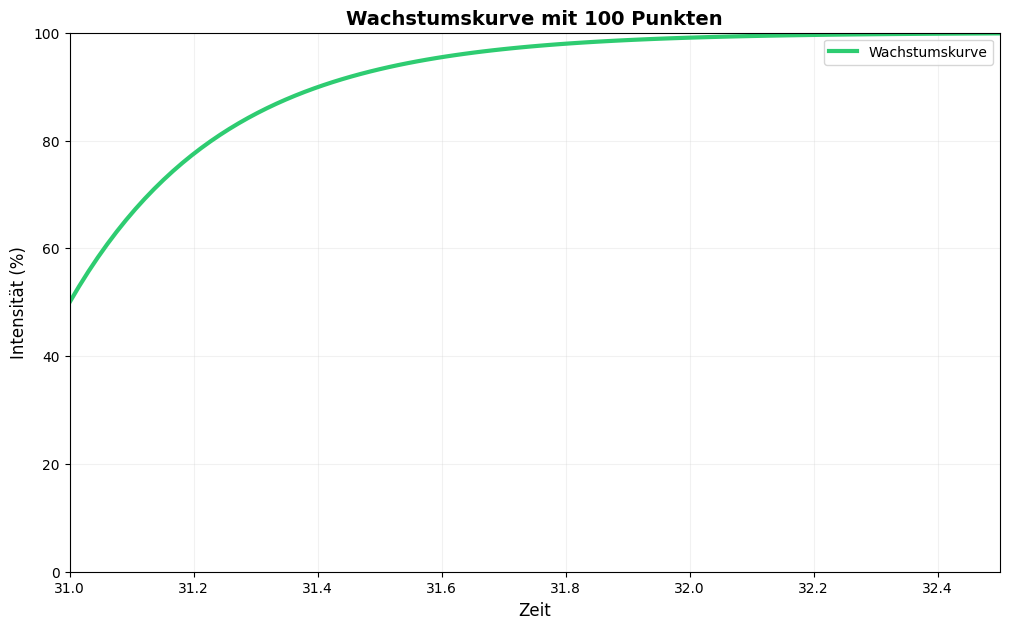


💡 Alles zusammen:
   1. linspace() für gleichmäßige Punkte
   2. Vektorisierte Berechnung mit NumPy
   3. Figure und Axes für die Struktur
   4. Automatische oder manuelle Achsengrenzen
   5. plt.show() zum Anzeigen (NICHT fig.show()!)


In [21]:
# 1. Erstelle gleichmäßig verteilte x-Werte mit linspace
growth_x = np.linspace(31, 32.5, 100)  # 100 Punkte für glatte Kurve
print("X-Werte (erste 10):")
print(growth_x[:10])

# 2. Berechne y-Werte mit vektorisierter Operation
# Exponentialfunktion: y = 50 + 50 * (1 - exp(-4 * (x - 31)))
growth_y = 50 + 50 * (1 - np.exp(-4 * (growth_x - 31)))
print("\nY-Werte (erste 10):")
print(growth_y[:10])

# 3. Erstelle Figure und Axes
fig, ax = plt.subplots(figsize=(12, 7), facecolor='white')
ax.set_facecolor('white')

# 4. Plotte die Kurve
ax.plot(growth_x, growth_y, color='#2ecc71', linewidth=3, label='Wachstumskurve')

# 5. Matplotlib setzt automatisch die Achsengrenzen basierend auf den Daten
print(f"\nAutomatische Achsengrenzen:")
print(f"X-Achse: {ax.get_xlim()}")
print(f"Y-Achse: {ax.get_ylim()}")

# 6. Wir können sie aber auch manuell setzen
ax.set_xlim(31, 32.5)
ax.set_ylim(0, 100)

# Styling
ax.set_xlabel('Zeit', fontsize=12)
ax.set_ylabel('Intensität (%)', fontsize=12)
ax.set_title('Wachstumskurve mit 100 Punkten', fontsize=14, weight='bold')
ax.grid(True, alpha=0.3, color='#d3d3d3')
ax.legend()

# 7. Zeige mit plt.show() (nicht fig.show()!)
plt.show()

print("\n💡 Alles zusammen:")
print("   1. linspace() für gleichmäßige Punkte")
print("   2. Vektorisierte Berechnung mit NumPy")
print("   3. Figure und Axes für die Struktur")
print("   4. Automatische oder manuelle Achsengrenzen")
print("   5. plt.show() zum Anzeigen (NICHT fig.show()!)")

<!-- Translation needed from German -->

### Performance-Vergleich: Array vs. Liste

### From kopie
*Compatible data types*


# Example

Let's start right away and create our first plot!

In [77]:
x = np.linspace(0, 5, 15)
y = x ** 2

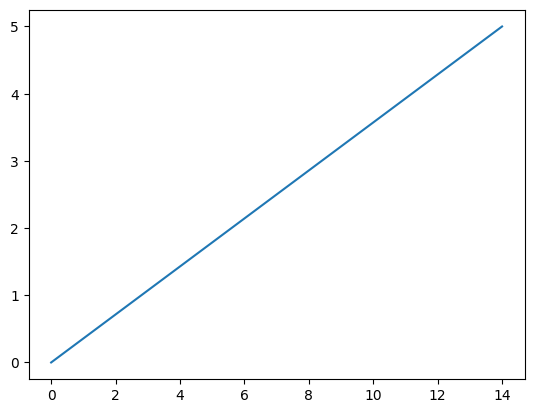

In [78]:
plt.plot(x)

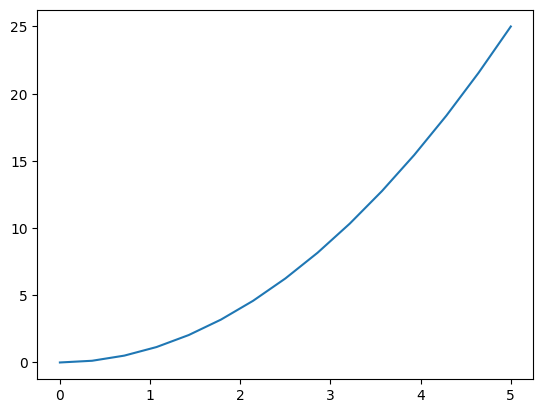

In [79]:
plt.plot(x, y)

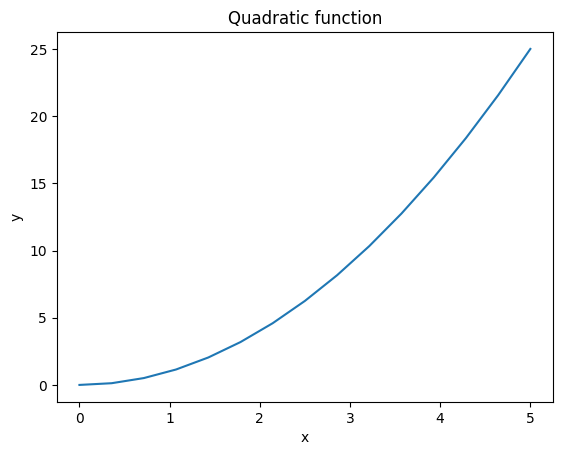

In [80]:
plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Quadratic function")
plt.show()

## Compatible data types

Matplotlib can deal with NumPy arrays (as just shown), base Python lists, and Pandas Series and Dataframes.

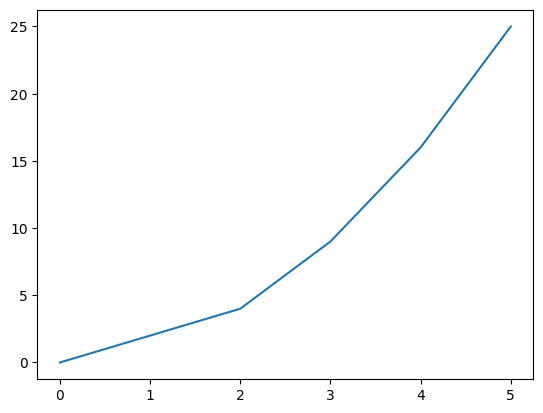

In [81]:
xdata = [0, 1, 2, 3, 4, 5]
ydata = [0, 2, 4, 9, 16, 25]
plt.plot(ydata)

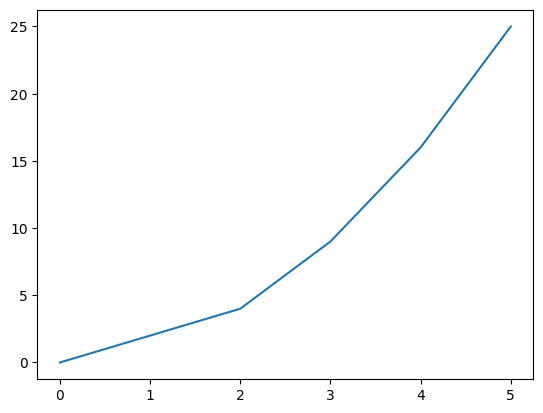

In [82]:
plt.plot(np.array(ydata))

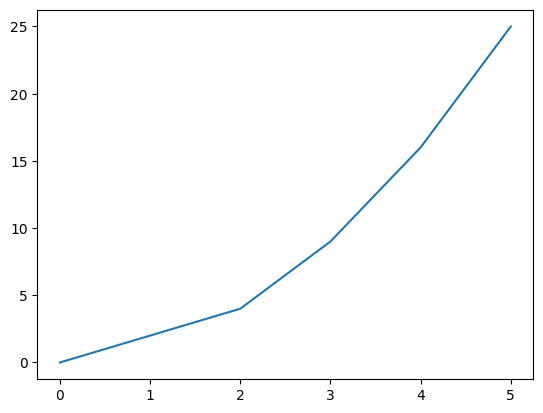

In [83]:
plt.plot(pd.Series(ydata))

In [84]:
df = pd.DataFrame({"x": xdata, "y": ydata})
df.head()

,x,y
0,0,0
1,1,2
2,2,4
3,3,9
4,4,16


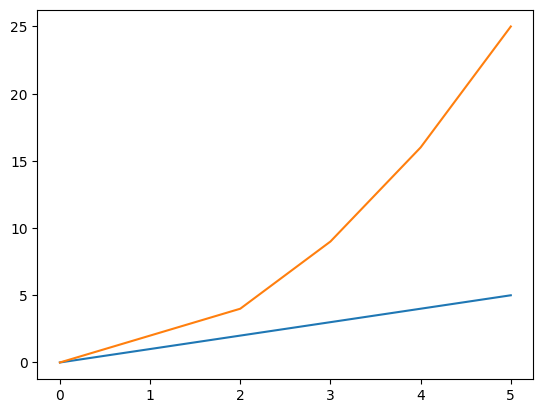

In [85]:
plt.plot(df) # each df's columns is plotted as a separate line and df index is the x-axis values

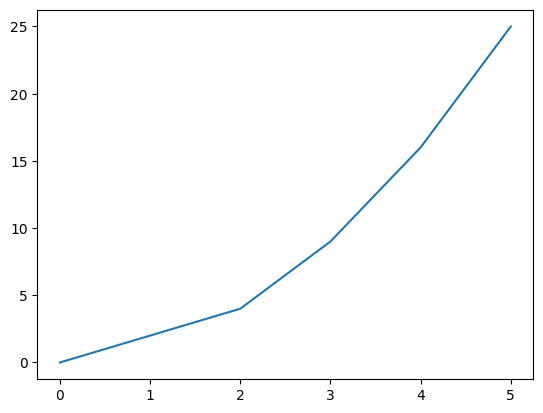

In [86]:
plt.plot(df["y"])

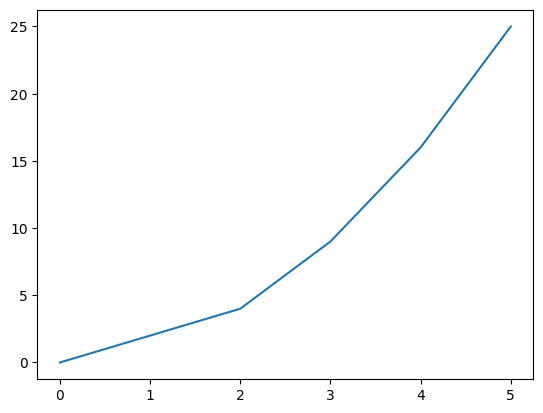

In [87]:
plt.plot(df.index, df["y"])

---

# Section 4: Basic Plot Types with NumPy

**Description:** Line plots, scatter plots, bar charts, and histograms

**Estimated Time:** 30-35 minutes

---


### From video
*Common plot types with NumPy*


The first version is explicit and beginner-friendly because you can clearly see which plot goes to which axes.

Once that feels natural, we can write the same idea more compactly.


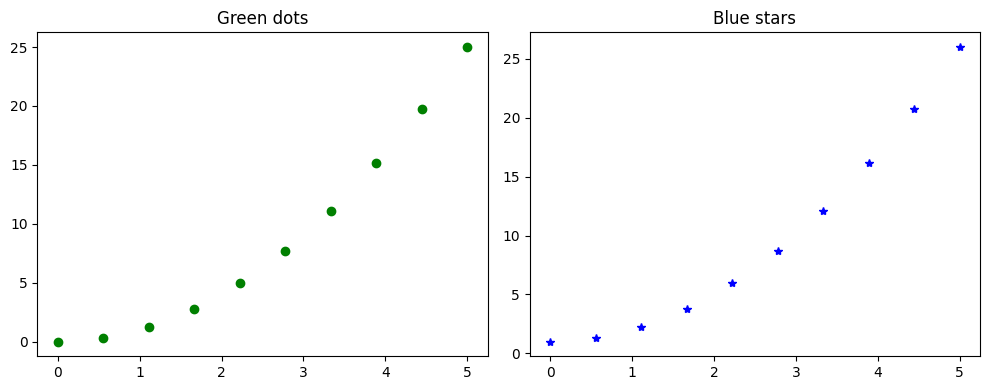

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, y_values, fmt, title in zip(
    axes,
    [y_panel, y_panel + 1],
    ['og', '*b'],
    ['Green dots', 'Blue stars']
):
    ax.plot(x_panel, y_values, fmt)
    ax.set_title(title)

plt.tight_layout()
plt.show()


### Figure anatomy: Figure, Axes, Axis, Artists

After seeing two side-by-side panels, the anatomy of a Matplotlib figure becomes easier to read.

![](https://matplotlib.org/stable/_images/anatomy.png)

A few definitions are worth locking in early:

- **Figure**: the full canvas or container
- **Axes**: one plotting area inside the figure
- **Axis**: the number line that creates ticks and tick labels
- **Artists**: everything visible, such as lines, points, text, legends, and titles

This is why `fig, ax = plt.subplots()` is such an important line:

- `fig` gives you control over the whole canvas
- `ax` gives you control over one plot region

In notebooks and scripts, prefer `plt.show()` rather than `fig.show()`. `plt.show()` is the standard display function and manages all open figures more reliably.


In [39]:
# This is where the object orientated name comes from 
type(fig), type(ax)

(matplotlib.figure.Figure, matplotlib.axes._axes.Axes)

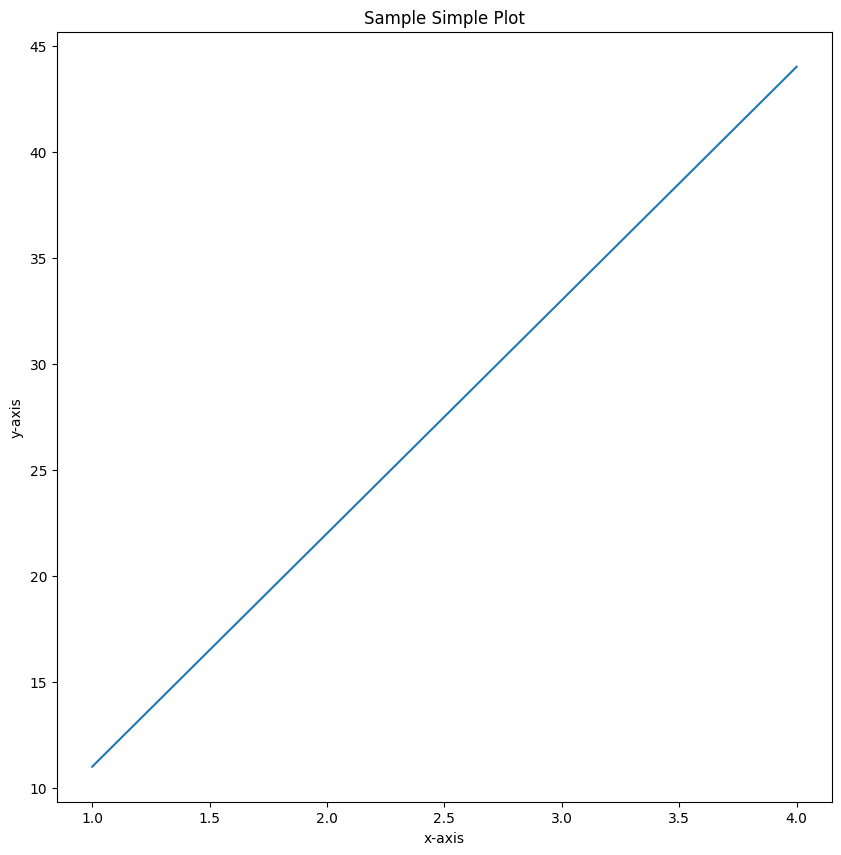

In [40]:
# A matplotlib workflow

# 0. Import and get matplotlib ready
%matplotlib inline
import matplotlib.pyplot as plt

# 1. Prepare data
x = [1, 2, 3, 4]
y = [11, 22, 33, 44]

# 2. Setup plot
fig, ax = plt.subplots(figsize=(10,10))

# 3. Plot data
ax.plot(x, y)

# 4. Customize plot
ax.set(title="Sample Simple Plot", xlabel="x-axis", ylabel="y-axis")

# 5. Save & show
fig.savefig("../images/simple-plot.png")

## 2. Making the most common type of plots using NumPy arrays

Matplotlib works especially well with numeric arrays. Before we plot lines, scatter plots, bars, and histograms, we need one small but powerful tool: `np.linspace()`.

We will use this section to connect several beginner ideas that belong together:

- `np.linspace()` for generating evenly spaced x-values
- arrays vs. lists vs. pandas objects
- line and scatter plots with both `pyplot` and the OO interface
- bar charts, histograms, and subplots


In [41]:
import numpy as np

### Deep dive into `np.linspace()`

`np.linspace(start, stop, num)` creates `num` evenly spaced values between `start` and `stop`.

That matters for plotting because:

- a few points give you a rough sketch
- many points give you a smooth-looking curve
- evenly spaced points are also useful when you want evenly spaced ticks later on


5 evenly spaced points:
[ 0.   2.5  5.   7.5 10. ]

100 evenly spaced points (first 10 shown):
[0.         0.1010101  0.2020202  0.3030303  0.4040404  0.50505051
 0.60606061 0.70707071 0.80808081 0.90909091]


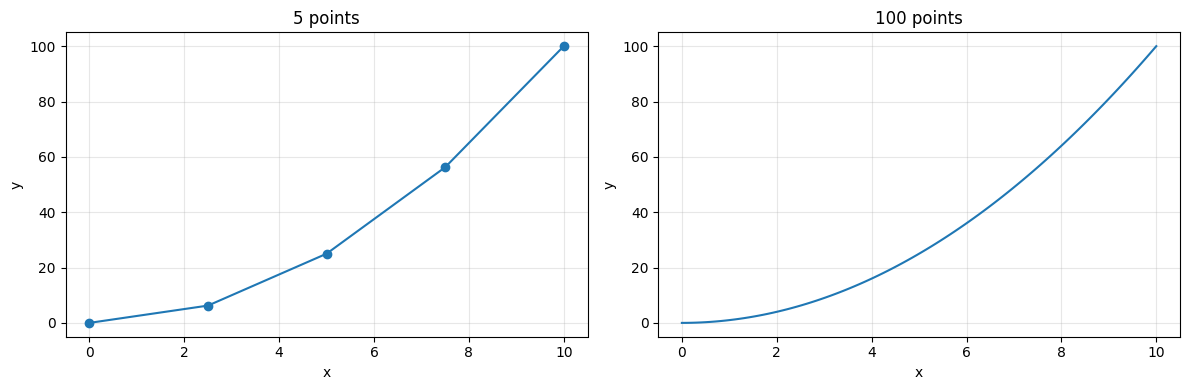

In [42]:
# A few points vs. many points
x_few = np.linspace(0, 10, 5)
x_many = np.linspace(0, 10, 100)

print('5 evenly spaced points:')
print(x_few)
print('\n100 evenly spaced points (first 10 shown):')
print(x_many[:10])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x_few, x_few**2, 'o-')
axes[0].set_title('5 points')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_many, x_many**2)
axes[1].set_title('100 points')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Arrays vs. lists vs. pandas objects

Matplotlib can plot all three, but they behave differently:

- Python lists are flexible and beginner-friendly
- NumPy arrays are best for numeric computations and vectorized operations
- pandas objects are convenient when your data already lives in a table

For plotting workflows, NumPy arrays and pandas objects usually make life easier than plain lists.


In [43]:
import pandas as pd

python_list = [1, 2, 3, 4]
numpy_array = np.array([1, 2, 3, 4])
pandas_series = pd.Series([1, 2, 3, 4], name='values')

print('Python list * 2 -> duplicates the list:')
print(python_list * 2)
print('\nNumPy array * 2 -> multiplies elementwise:')
print(numpy_array * 2)
print('\npandas Series * 2 -> also multiplies elementwise:')
print(pandas_series * 2)


Python list * 2 -> duplicates the list:
[1, 2, 3, 4, 1, 2, 3, 4]

NumPy array * 2 -> multiplies elementwise:
[2 4 6 8]

pandas Series * 2 -> also multiplies elementwise:
0    2
1    4
2    6
3    8
Name: values, dtype: int64


### Line

Line is the default type of visualization in Matplotlib. Usually, unless specified otherwise, your plots will start out as lines.

In [44]:
# Create an array
x = np.linspace(0, 10, 100)
x[:10]

array([0.        , 0.1010101 , 0.2020202 , 0.3030303 , 0.4040404 ,
       0.50505051, 0.60606061, 0.70707071, 0.80808081, 0.90909091])

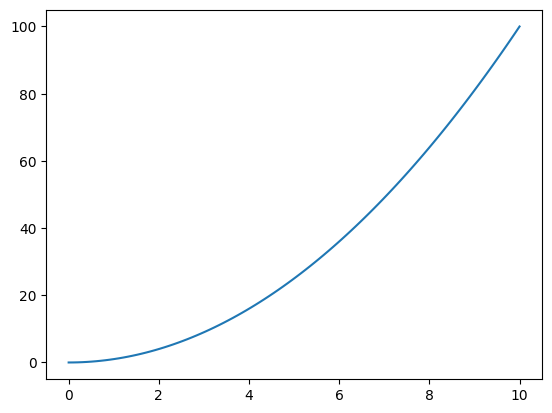

In [45]:
# The default plot is line
fig, ax = plt.subplots()
ax.plot(x, x**2);

### Scatter

Before drawing a true scatter plot, it helps to notice something important: `plt.plot()` draws a **line chart by default** if you only pass one sequence of values.


### From kopie
*Scatterplot variations and basic plots*


##  Axes

A figure can have one or more subplots inside it called Axes, arranged in rows and columns. Every figure has at least one Axes. Don't confuse Axes with X and Y axis: they are different!

The Axes objects, such as `ax1` and `ax2` above, are what you think of as 'a plot'. It is the region of the image with the data space. A given figure can contain many Axes, but a given Axes object can only be in one Figure. The **Axes** contains two (or three in the case of 3D) **Axis** objects (be aware of the difference between Axes and Axis!!) which take care of the data limits (the data limits can also be controlled via `set_xlim()` and `set_ylim()` Axes methods).

Each Axes has:

1. a title (set via `set_title()`);
1. a x-label (set via `set_xlabel()`);
1. a y-label (set via `set_ylabel()`).

The Axes class and its member functions are the primary entry point to working with the object-oriented programming (OOP) interface.

## Axis

These are the number-line-like objects. They take care of setting the graph limits and generating the ticks (the marks on the axis) and ticklabels (strings labeling the ticks). The location of the ticks is determined by a Locator object and the ticklabel strings are formatted by a Formatter. The combination of the correct Locator and Formatter gives very fine control over the tick locations and labels.

## Artist

Basically everything you can see on the figure is an artist (even the Figure, Axes, and Axis objects). This includes Text objects, Line2D objects, collection objects, Patch objects ... (you get the idea). When the figure is rendered, all of the artists are drawn to the canvas. Most Artists are tied to an Axes; such an Artist cannot be shared by multiple Axes, or moved from one to another.

---

## Simple scatterplot

We have already seen what `plt.plot()` creates if we you call it on an arbitrary sequence of numbers:

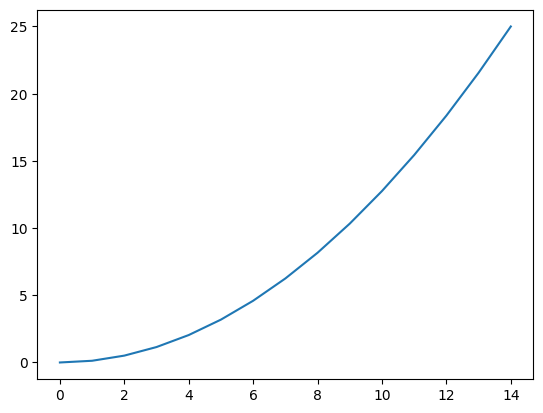

In [96]:
plt.plot(y)

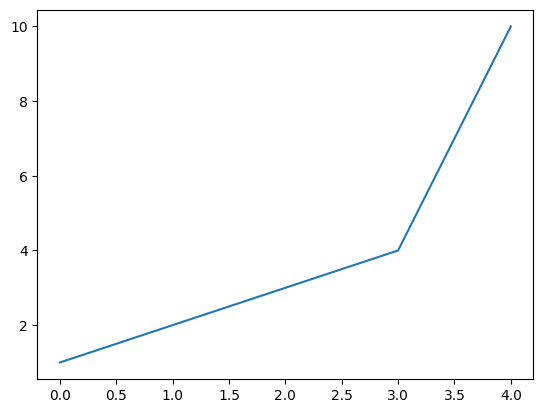

In [97]:
plt.plot([1, 2, 3, 4, 10])

Matplotlib draws a **line chart** automatically, assuming the values of the X-axis start from zero, going up to as many items in the data.

Notice the line `matplotlib.lines.Line2D` in the above code output?

That's because Matplotlib returns the plot object itself besides drawing the plot.

If you only want to see the plot (e.g. in a non-interactive script), add `plt.show()` at the end and execute all the lines in one shot.

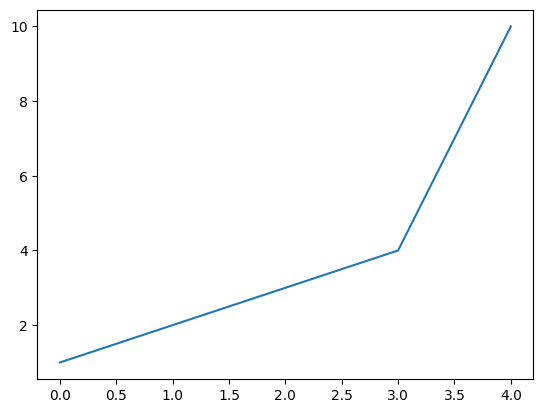

In [98]:
plt.plot([1, 2, 3, 4, 10])
plt.show()

Another possibility is to end the `plt.plot()` command with a semicolon:

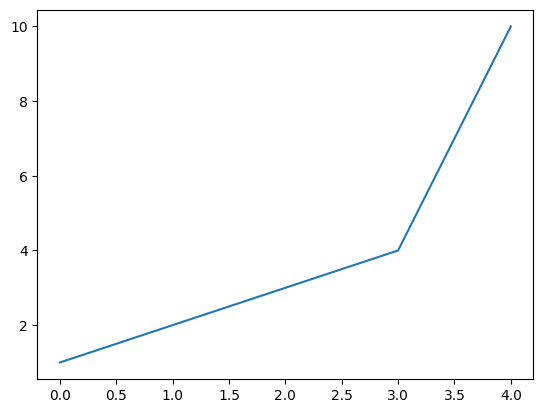

In [99]:
plt.plot([1, 2, 3, 4, 10]);

So, this is not a scatterplot yet, but a line chart. How to draw a real scatterplot?

Let's first focus a bit more about what arguments `plt.plot()` expects.

The three basic arguments are: `plt.plot(x, y, format)` (in this specific order!)

The `format` is a string representing a shorthand combination of `[marker][line][color]`.

Each of them is optional: if not provided, the value from the style cycle is used. Exception: if `line` is given, but no `marker`, the data will be a line without markers.

Commonly used markers are:

- `'.'` (point)
- `'o'` (circle)
- `'*'` (star)
- `'D'` (diamond)

Line styles are:

- `'-'` (solid)
- `'--'` (dashed)
- `'-.'` (dash-dot)
- `':'` (dotted)

Colors are single-letter abbreviations of color names, such as:

- `'b'` (blue)
- `'g'` (green)
- `'r'` (red)
- `'k'` (black)

**Example:** The format `'o-g'` has 3 characters standing for: *green circles with solid line*.
By omitting the `line` part, you will be left with green circles (`‘og’`).

Note that:

1. `format` is not necessarily a 3-character string, since some `line` styles may take up 2 characters (e.g. `'--'`, `'-.'`).
2. you can provide the combination in any order (e.g. `[color][marker][line]`), but the parsing may be ambiguous.

Few commonly used short hand format examples are:

- `'*--r'` : red stars with dashed lines
- `'s:k'` : black squares with dotted line ('k' = black)
- `'D-.b'` : blue diamonds with dash-dot line

For a complete list of colors, markers and linestyles, check out the `help(plt.plot)` command (also [online](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html)).

Let's draw a scatterplot with green dots:

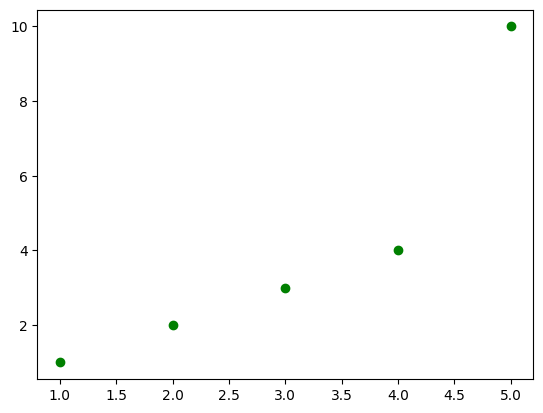

In [100]:
# 'og' stands for green circles
plt.plot([1, 2, 3, 4, 5], [1, 2, 3, 4, 10], 'og')
plt.show()

Now how to plot another set of 5 points of different color in the same figure?

Simply call `plt.plot()` again: it will add those point to the same picture.

You might wonder, why it does not draw these points in a new panel altogether? I will come to that in the next section.

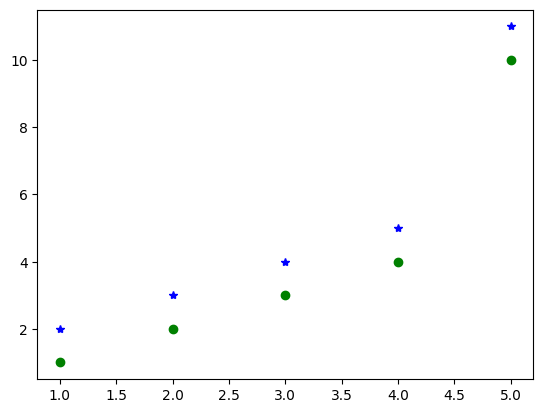

In [101]:
# Draw two sets of points
xx = np.array([1, 2, 3, 4, 5])
yy = np.array([1, 2, 3, 4, 10])
plt.plot(xx, yy, "og")  # green dots
plt.plot(xx, yy+1, "*b")  # blue stars
plt.show()

Looks good. Now let’s add the basic plot features: Title, Legend, X and Y axis labels.

The `plt` object has corresponding methods to add each of these.

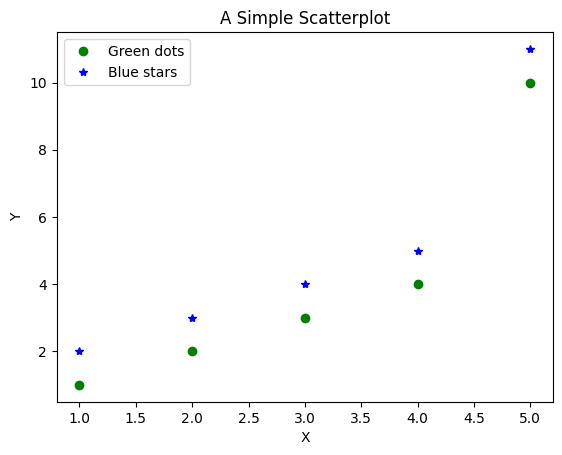

In [102]:
plt.plot(xx, yy, "og", label="Green dots") # we attach a label to be used by the legend
plt.plot(xx, yy+1, "*b", label="Blue stars")

plt.title("A Simple Scatterplot")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend(loc="best")  # legend text comes from the plot's label parameter
plt.show()

# other choices for loc are: 'upper right', 'lower right', 'center', 'right', 'center right' (similarly for left)

How to increase the size of the figure?

The easy way to do it is by setting the `figsize` inside `plt.figure()` method. We also set the x-y axis limits.

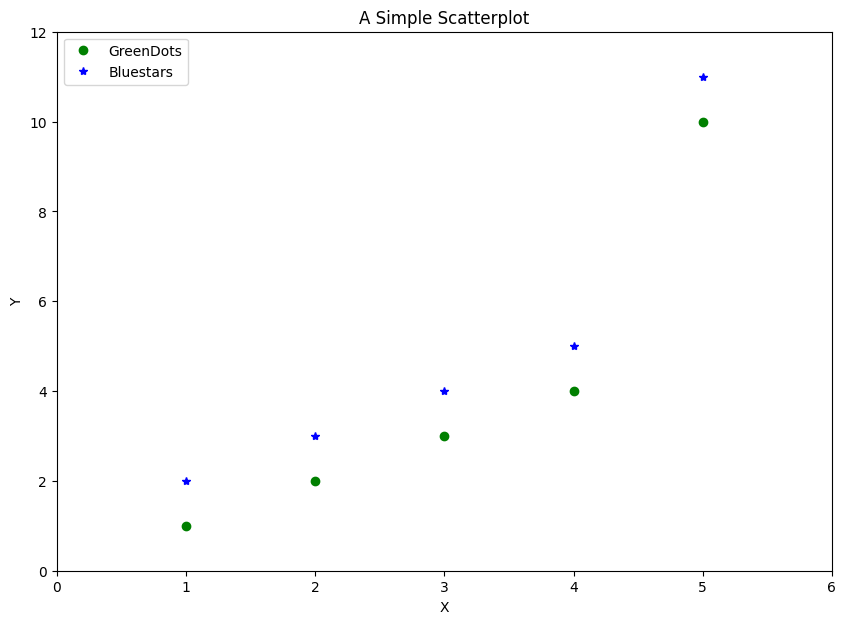

In [103]:
plt.figure(figsize=(10, 7))  # (width, height)

plt.plot(xx, yy, "og", label="GreenDots")  # green dots
plt.plot(xx, yy+1, "*b", label="Bluestars")  # blue stars

plt.xlim(0, 6) # x axis limits
plt.ylim(0, 12) # y axis limits

plt.title("A Simple Scatterplot")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend(loc="best")
plt.show()

---

# Section 5: Plotting with Pandas DataFrames

**Description:** Real-world data, DataFrame plotting, and pandas integration

**Estimated Time:** 25-30 minutes

---


### From video
*Pandas integration with real datasets*


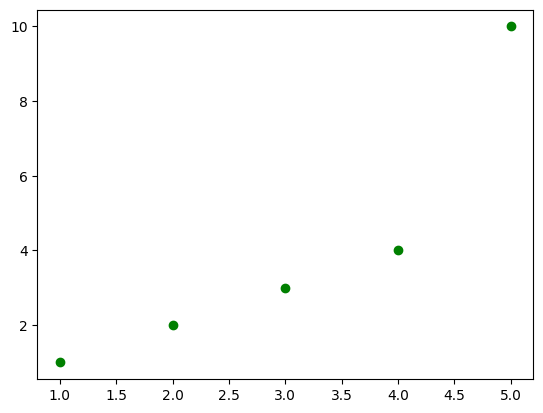

In [47]:
# A real scatter-like point display using format strings
plt.plot([1, 2, 3, 4, 5], [1, 2, 3, 4, 10], 'og')
plt.show()


Now let's add a second set of points to the **same axes**. This is an important moment conceptually: calling `plt.plot()` again does **not** create a new panel. It adds more marks to the current plotting area.


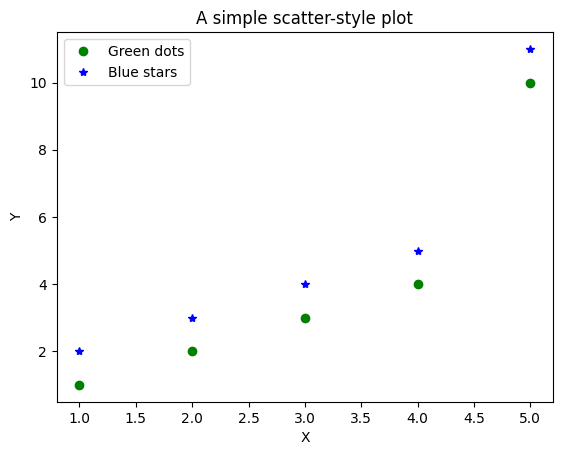

In [48]:
xx = np.array([1, 2, 3, 4, 5])
yy = np.array([1, 2, 3, 4, 10])

plt.plot(xx, yy, 'og', label='Green dots')
plt.plot(xx, yy + 1, '*b', label='Blue stars')
plt.title('A simple scatter-style plot')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend(loc='best')
plt.show()


We can also make the same plot larger and control the visible axis range.


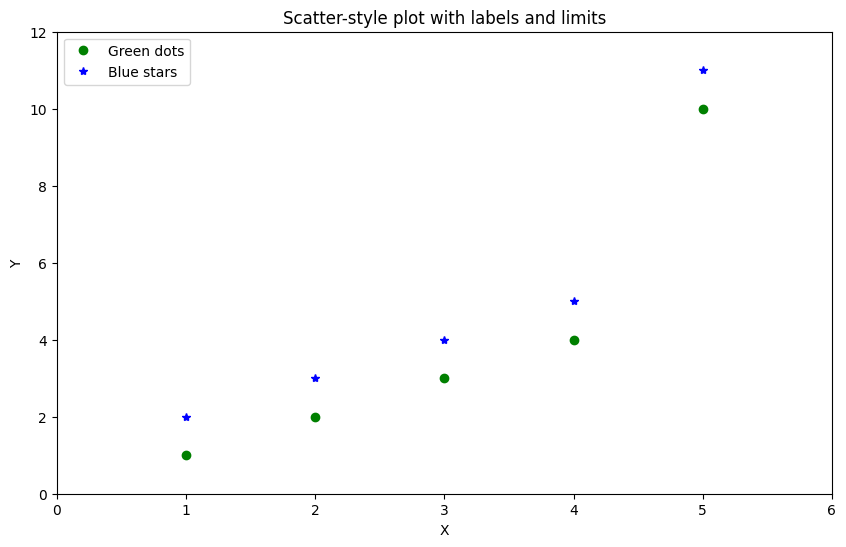

In [49]:
plt.figure(figsize=(10, 6))
plt.plot(xx, yy, 'og', label='Green dots')
plt.plot(xx, yy + 1, '*b', label='Blue stars')
plt.xlim(0, 6)
plt.ylim(0, 12)
plt.title('Scatter-style plot with labels and limits')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend(loc='best')
plt.show()


The same idea becomes more explicit in the OO interface. This is the version to prefer once you are doing anything beyond a quick one-liner.


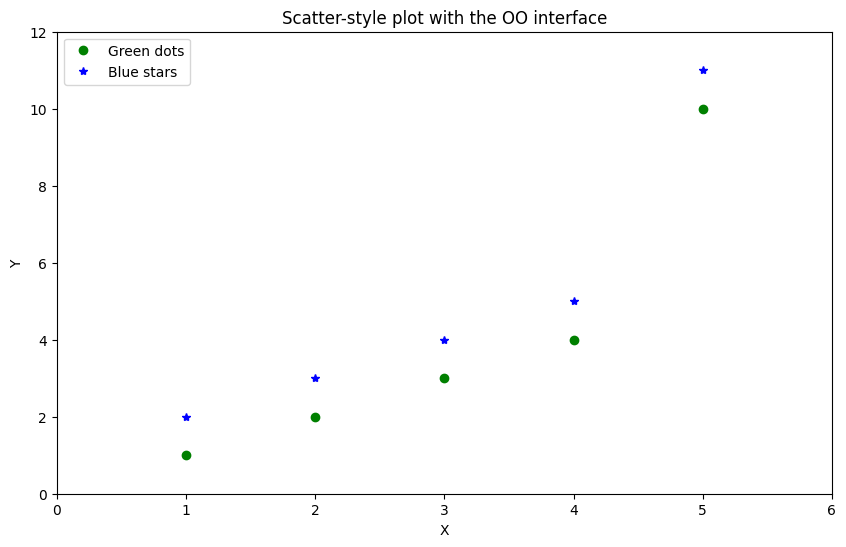

In [50]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(xx, yy, 'og', label='Green dots')
ax.plot(xx, yy + 1, '*b', label='Blue stars')
ax.set_xlim(0, 6)
ax.set_ylim(0, 12)
ax.set_title('Scatter-style plot with the OO interface')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.legend(loc='best')
plt.show()


If you want a dedicated scatter API instead of marker-only `plot()` calls, use `plt.scatter(...)` or `ax.scatter(...)`.


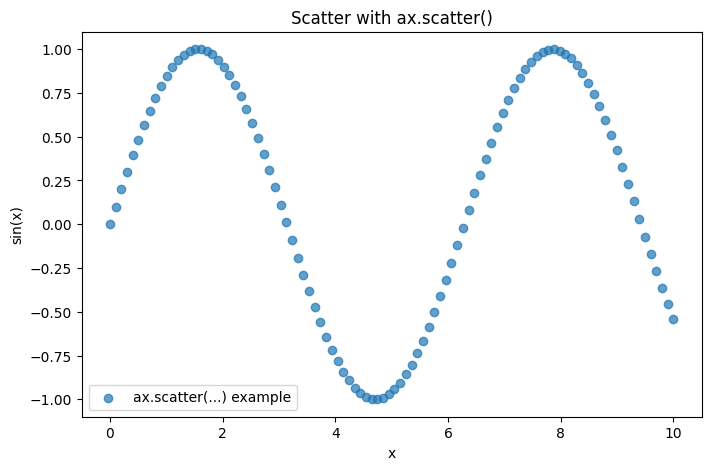

In [51]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x, np.sin(x), alpha=0.7, label='ax.scatter(...) example')
ax.set_title('Scatter with ax.scatter()')
ax.set_xlabel('x')
ax.set_ylabel('sin(x)')
ax.legend(loc='best')
plt.show()


### Bar
* Vertical
* Horizontal

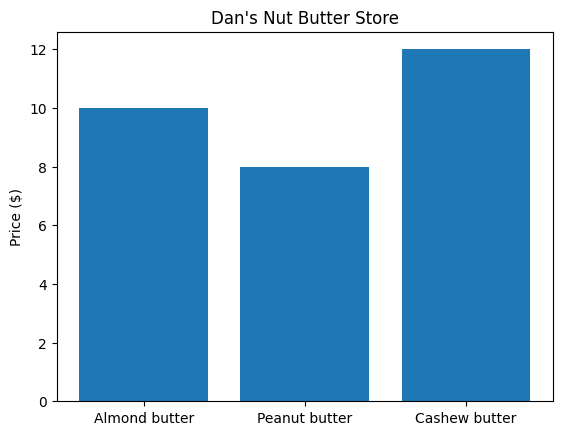

In [52]:
# You can make plots from a dictionary
nut_butter_prices = {"Almond butter": 10,
                     "Peanut butter": 8,
                     "Cashew butter": 12}
fig, ax = plt.subplots()
ax.bar(nut_butter_prices.keys(), nut_butter_prices.values())
ax.set(title="Dan's Nut Butter Store", ylabel="Price ($)");

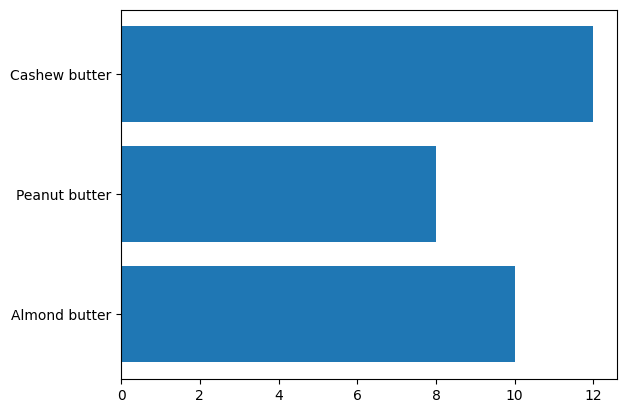

In [53]:
fig, ax = plt.subplots()
ax.barh(list(nut_butter_prices.keys()), list(nut_butter_prices.values()));

### Histogram (hist)

* Could show image of normal distribution here

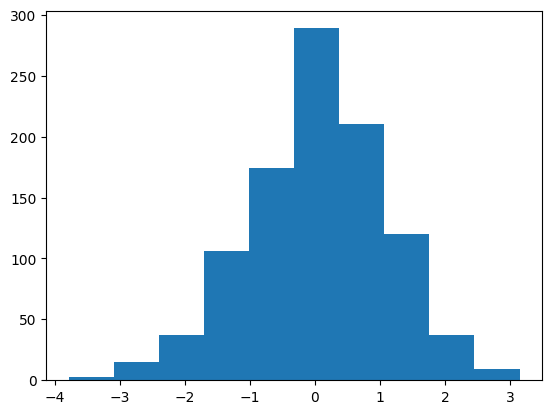

In [54]:
# Make some data from a normal distribution
x = np.random.randn(1000) # pulls data from a normal distribution

fig, ax = plt.subplots()
ax.hist(x);

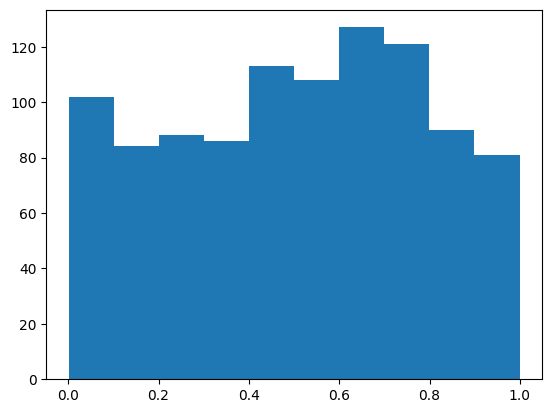

In [55]:
x = np.random.random(1000) # random data from random distribution

fig, ax = plt.subplots()
ax.hist(x);

### Subplots

Subplots are multiple plotting areas inside one figure.

Before the larger grid examples, it helps to see the most common beginner version first: two panels side by side. This is where the OO pattern becomes especially useful because each panel gets its own `ax` object.


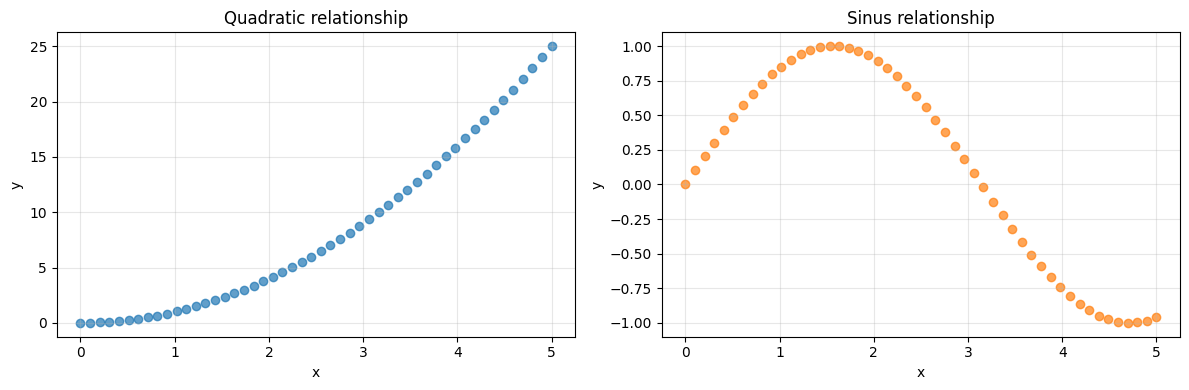

In [56]:
# Two scatterplots in different panels
x_panel = np.linspace(0, 5, 50)
y_panel_1 = x_panel**2
y_panel_2 = np.sin(x_panel)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(x_panel, y_panel_1, color='tab:blue', alpha=0.7)
axes[0].set_title('Quadratic relationship')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(x_panel, y_panel_2, color='tab:orange', alpha=0.7)
axes[1].set_title('Sinus relationship')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


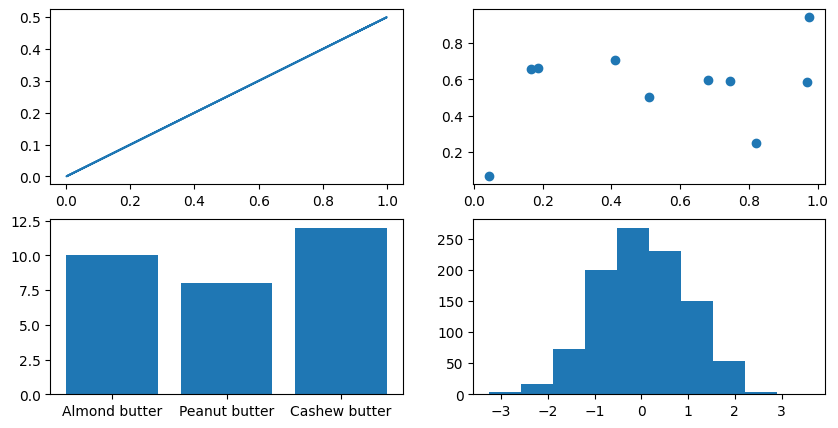

In [57]:
# Option 1: Create multiple subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, 
                                             ncols=2, 
                                             figsize=(10, 5))

# Plot data to each axis
ax1.plot(x, x/2);
ax2.scatter(np.random.random(10), np.random.random(10));
ax3.bar(nut_butter_prices.keys(), nut_butter_prices.values());
ax4.hist(np.random.randn(1000));

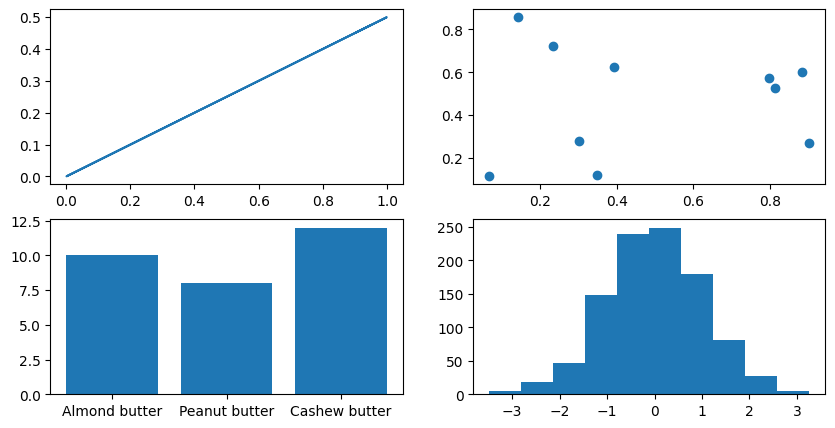

In [58]:
# Option 2: Create multiple subplots
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 5))

# Index to plot data
ax[0, 0].plot(x, x/2);
ax[0, 1].scatter(np.random.random(10), np.random.random(10));
ax[1, 0].bar(nut_butter_prices.keys(), nut_butter_prices.values());
ax[1, 1].hist(np.random.randn(1000));

## 3. Plotting data directly with pandas
This section uses the pandas `pd.plot()` method on a DataFrame to plot columns directly.

* https://datatofish.com/plot-dataframe-pandas/
* https://pandas.pydata.org/pandas-docs/stable/user_guide/visualization.html

* `line`
* `scatter`
* `bar`
* `hist`
* `df.plot(subplots=True, figsize=(6, 6))`

To plot data with pandas, we first have to import it as `pd`.

In [59]:
import pandas as pd

Now we need some data to check out.

In [60]:
# Let's import the car_sales dataset
car_sales = pd.read_csv("../data/car-sales.csv")
car_sales

FileNotFoundError: [Errno 2] No such file or directory: '../data/car-sales.csv'

### Line
* Concept
* DataFrame

Often, reading things won't make sense. Practice writing code for yourself, get it out of the docs and into your workspace. See what happens when you run it.

Let's start with trying to replicate the pandas visualization documents.

In [ ]:
# Start with some dummy data
ts = pd.Series(np.random.randn(1000),
               index=pd.date_range('1/1/2020', periods=1000))
ts

2020-01-01    0.738301
2020-01-02   -0.436335
2020-01-03    1.552973
2020-01-04   -0.721055
2020-01-05   -0.522301
                ...   
2022-09-22   -0.529207
2022-09-23   -0.760224
2022-09-24    0.399311
2022-09-25   -0.669529
2022-09-26    0.238585
Freq: D, Length: 1000, dtype: float64

In [ ]:
# What does cumsum() do?
ts.cumsum()

2020-01-01     0.738301
2020-01-02     0.301966
2020-01-03     1.854938
2020-01-04     1.133883
2020-01-05     0.611582
                ...    
2022-09-22   -36.324290
2022-09-23   -37.084515
2022-09-24   -36.685204
2022-09-25   -37.354733
2022-09-26   -37.116148
Freq: D, Length: 1000, dtype: float64

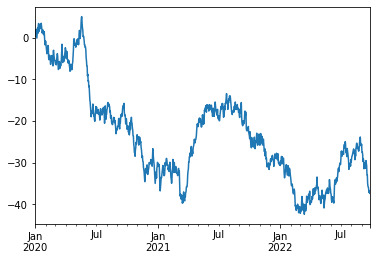

In [ ]:
ts.cumsum().plot();

### Working with actual data

Let's do a little data manipulation on our `car_sales` DataFrame.

In [ ]:
# Remove price column symbols
car_sales["Price"] = car_sales["Price"].str.replace(r'[\$,.]', '', regex=True)
car_sales

,Make,Colour,Odometer (KM),Doors,Price
0,Toyota,White,150043,4,400000
1,Honda,Red,87899,4,500000
2,Toyota,Blue,32549,3,700000
3,BMW,Black,11179,5,2200000
4,Nissan,White,213095,4,350000
5,Toyota,Green,99213,4,450000
6,Honda,Blue,45698,4,750000
7,Honda,Blue,54738,4,700000
8,Toyota,White,60000,4,625000
9,Nissan,White,31600,4,970000


In [ ]:
# Remove last two zeros
car_sales["Price"] = car_sales["Price"].str[:-2]
car_sales

,Make,Colour,Odometer (KM),Doors,Price
0,Toyota,White,150043,4,4000
1,Honda,Red,87899,4,5000
2,Toyota,Blue,32549,3,7000
3,BMW,Black,11179,5,22000
4,Nissan,White,213095,4,3500
5,Toyota,Green,99213,4,4500
6,Honda,Blue,45698,4,7500
7,Honda,Blue,54738,4,7000
8,Toyota,White,60000,4,6250
9,Nissan,White,31600,4,9700


In [ ]:
# Add a date column
car_sales["Sale Date"] = pd.date_range("1/1/2020", periods=len(car_sales))
car_sales

,Make,Colour,Odometer (KM),Doors,Price,Sale Date
0,Toyota,White,150043,4,4000,2020-01-01
1,Honda,Red,87899,4,5000,2020-01-02
2,Toyota,Blue,32549,3,7000,2020-01-03
3,BMW,Black,11179,5,22000,2020-01-04
4,Nissan,White,213095,4,3500,2020-01-05
5,Toyota,Green,99213,4,4500,2020-01-06
6,Honda,Blue,45698,4,7500,2020-01-07
7,Honda,Blue,54738,4,7000,2020-01-08
8,Toyota,White,60000,4,6250,2020-01-09
9,Nissan,White,31600,4,9700,2020-01-10


In [ ]:
# Make total sales column (doesn't work, adds as string)
#car_sales["Total Sales"] = car_sales["Price"].cumsum()

# Oops... want them as int's not string
car_sales["Total Sales"] = car_sales["Price"].astype(int).cumsum()
car_sales

,Make,Colour,Odometer (KM),Doors,Price,Sale Date,Total Sales
0,Toyota,White,150043,4,4000,2020-01-01,4000
1,Honda,Red,87899,4,5000,2020-01-02,9000
2,Toyota,Blue,32549,3,7000,2020-01-03,16000
3,BMW,Black,11179,5,22000,2020-01-04,38000
4,Nissan,White,213095,4,3500,2020-01-05,41500
5,Toyota,Green,99213,4,4500,2020-01-06,46000
6,Honda,Blue,45698,4,7500,2020-01-07,53500
7,Honda,Blue,54738,4,7000,2020-01-08,60500
8,Toyota,White,60000,4,6250,2020-01-09,66750
9,Nissan,White,31600,4,9700,2020-01-10,76450


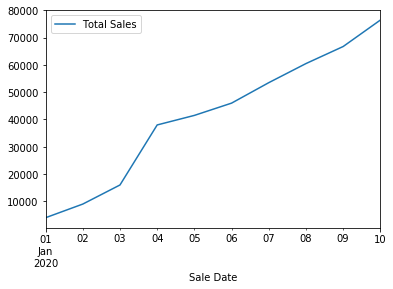

In [ ]:
car_sales.plot(x='Sale Date', y='Total Sales');

### Scatter
* Concept
* DataFrame

### Advanced: Using Column Names Directly in Scatter Plots

One of the most powerful features of matplotlib's `plt.scatter()` function is the ability to use column names directly when working with pandas DataFrames. This is achieved through the `data` parameter.

**Key Parameters:**

- **`data` parameter**: Allows you to pass a DataFrame and reference columns by name as strings
- **`s` parameter**: Controls the size of points - can be a single value or a column name for variable sizing
- **`c` parameter**: Controls the color of points - can be a single color or a column name for color mapping

**Benefits of this approach:**

1. **Cleaner code**: No need to repeatedly reference the DataFrame (e.g., `df['column']`)
2. **More readable**: Column names as strings are easier to understand at a glance
3. **Less error-prone**: Reduces the chance of indexing mistakes
4. **Consistent syntax**: Works seamlessly with other matplotlib functions

In [ ]:
# Advanced scatter plot using column names directly
plt.figure(figsize=(10, 6))
plt.scatter("area", "poptotal", data=midwest, s="dot_size", c="popdensity")
plt.xlabel("Area")
plt.ylabel("Total Population")
plt.title("Population vs Area (sized by dot_size, colored by density)")
plt.colorbar(label="Population Density")
plt.show()

**Understanding this visualization:**

In the example above, we're creating a sophisticated scatter plot that encodes **four dimensions** of data simultaneously:

1. **X-axis (`"area"`)**: The geographic area of each county
2. **Y-axis (`"poptotal"`)**: The total population of each county
3. **Point size (`s="dot_size"`)**: Each point's size varies based on the `dot_size` column value
4. **Point color (`c="popdensity"`)**: Each point's color represents population density, with a colorbar showing the scale

**When to use this technique:**

- **Exploratory data analysis**: Quickly visualize relationships between multiple variables
- **Multivariate analysis**: When you need to show more than just x-y relationships
- **Pattern detection**: Size and color encoding help identify clusters and outliers
- **Presentation**: Creates visually rich plots that convey complex information efficiently

This approach is particularly useful when working with datasets that have many related variables, as it allows you to explore multiple relationships in a single visualization without creating numerous separate plots.

---

# Section 6: Subplots and Multi-Panel Figures

**Description:** Creating complex layouts with multiple axes

**Estimated Time:** 25-30 minutes

---


### From kopie
*Multiple panels and subplots*


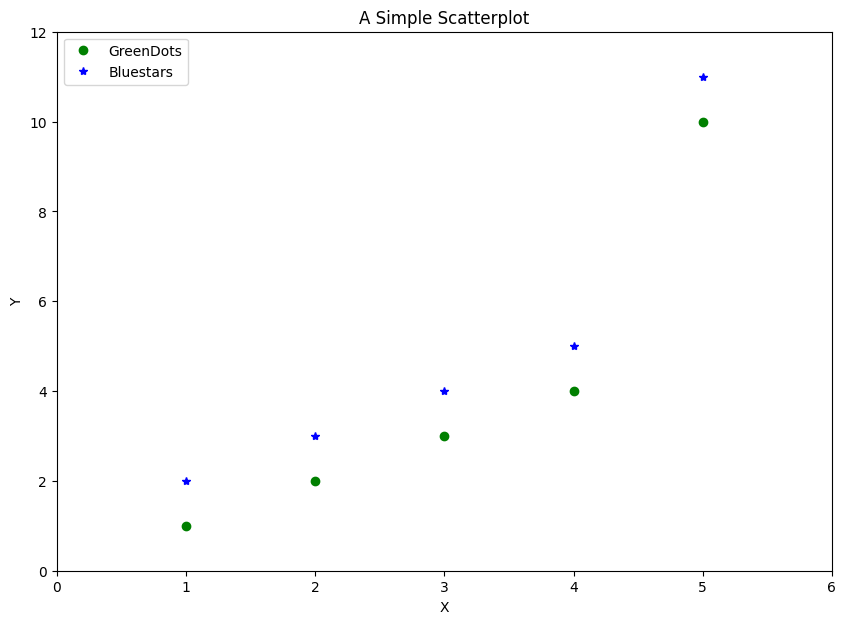

In [104]:
fig, ax = plt.subplots(figsize=(10, 7))  # (width, height)

ax.plot(xx, yy, "og", label="GreenDots")  # green dots
ax.plot(xx, yy+1, "*b", label="Bluestars")  # blue stars

ax.set_xlim(0, 6) # x axis limits
ax.set_ylim(0, 12) # y axis limits

ax.set_title("A Simple Scatterplot")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.legend()
plt.show()

## How to draw 2 scatterplots in different panels

Let's understand figure and axes in little more detail.

Suppose I want to draw our two sets of points (green rounds and blue stars) in two separate plots side-by-side instead of the same plot.

You can do that by creating two separate subplots, or Axes, using `plt.subplots(1, 2)`: this means to creates 1 row with 2 subplots. The command returns two objects:

1. the figure
1. the axes (subplots) inside the figure

![](https://www.machinelearningplus.com/wp-content/uploads/2019/01/99_matplotlib_structure-1.png)

Previously, I called `plt.plot()` to draw the points. Since there was only one axes by default, it drew the points on that axes itself.

But now, since you want the points drawn on different subplots (axes), you have to call the plot function **on the respective axes**.

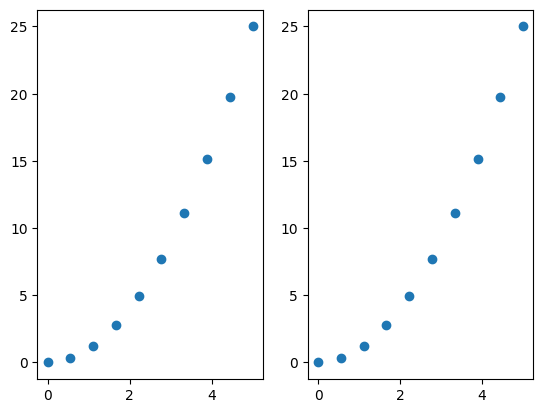

In [105]:
# Create Figure and Subplots, capturing them in separate variables
x = np.linspace(0, 5, 10)
y = x ** 2

fig, axes = plt.subplots(1, 2)

ax1 = axes[0]
ax2 = axes[1]

# Plot
ax1.plot(x, y, 'o')
ax2.plot(x, y, 'o')

plt.show()

The above code seems quite repetitive and can be further optimized:

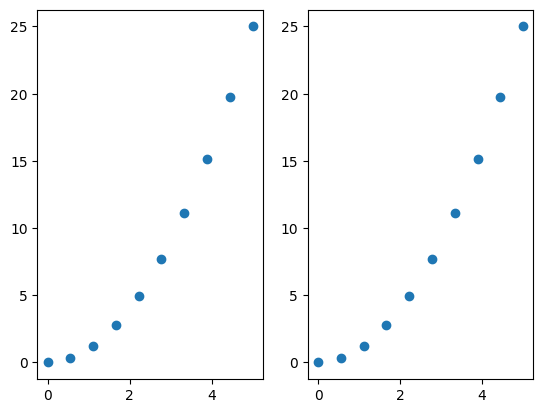

In [106]:
fig, axes = plt.subplots(1, 2)

for ax in axes:
    ax.plot(x, y, 'o')

plt.show()

Let's add titles and x-y labels:

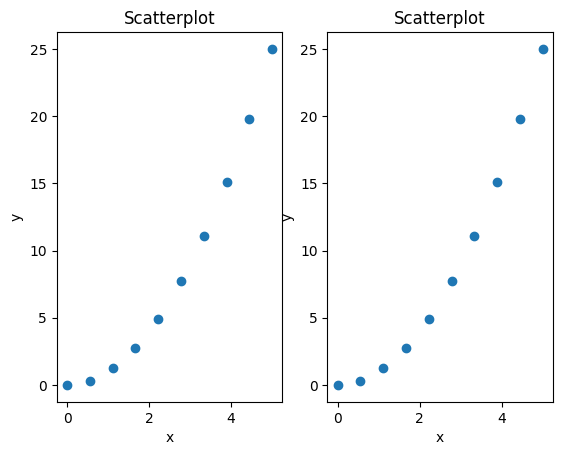

In [107]:
fig, axes = plt.subplots(1, 2)

for ax in axes:
    ax.plot(x, y, 'o')
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("Scatterplot")

plt.show()

Quite good, but figure axes and labels overlap: we fix this with the `fig.tight_layout` method, which automatically adjusts the positions of the axes on the figure canvas so that there is no overlapping content:

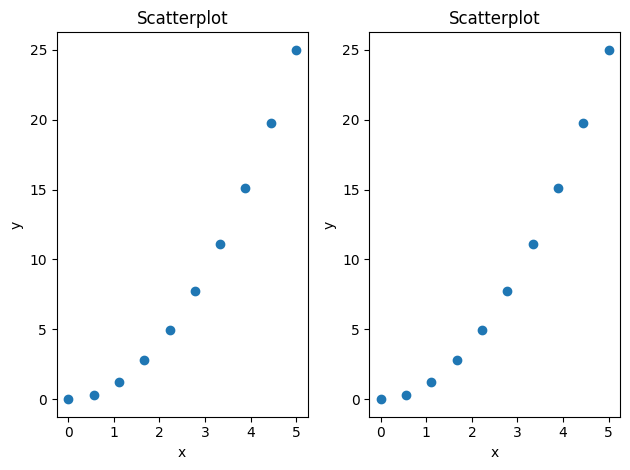

In [108]:
fig, axes = plt.subplots(1, 2)

for ax in axes:
    ax.plot(x, y, 'o')
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("Scatterplot")

fig.tight_layout()
plt.show()

Better, but we notice that the y-axis labels of the right-hand panel are redundant: in the following example, we create two Axes sharing the y axis.

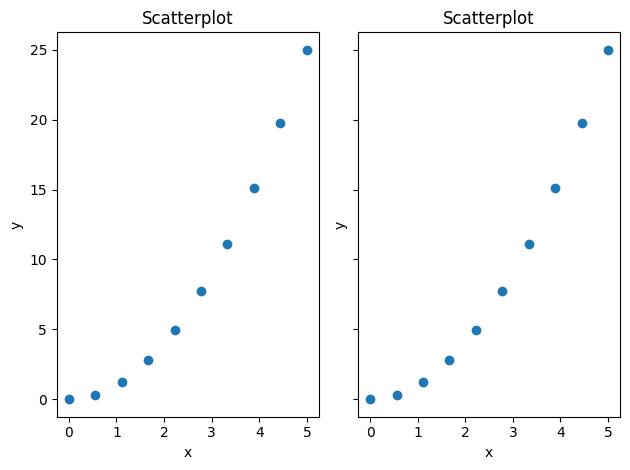

In [109]:
fig, axes = plt.subplots(1, 2, sharey=True)

for ax in axes:
    ax.plot(x, y, 'o')
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("Scatterplot")

fig.tight_layout()
plt.show()

### From video
*Subplots examples*


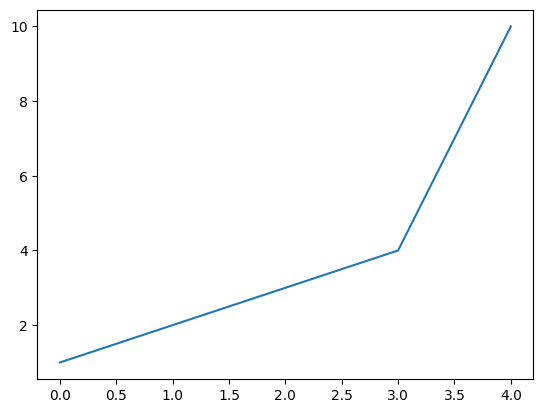

In [46]:
plt.plot([1, 2, 3, 4, 10]);


Matplotlib interprets that as y-values and automatically uses index positions for x-values.

To control the appearance more precisely, `plt.plot()` can take three basic inputs in this order:

`plt.plot(x, y, format)`

The optional `format` string is shorthand for a combination of marker, line style, and color.

Common examples:

- `'og'` = green circles, no connecting line
- `'*b'` = blue stars, no connecting line
- `'o-g'` = green circles with a solid line
- `'--r'` = red dashed line


### From fundamentals
*Multiple subplots practical example*


### Visualisierung: Warum mehr Punkte = glattere Kurven

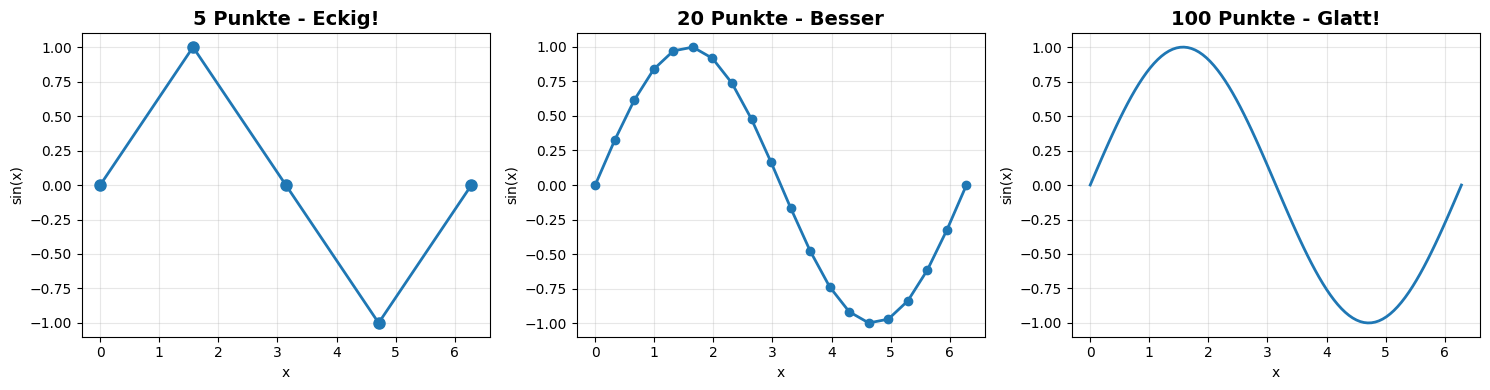


💡 Fazit: Mehr Punkte = glattere Kurven!
   Für unsere Wachstumskurve nutzen wir 100 Punkte.


In [12]:
# Erstelle eine Sinuskurve mit unterschiedlich vielen Punkten
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

# Mit 5 Punkten - sehr eckig!
x1 = np.linspace(0, 2*np.pi, 5)
y1 = np.sin(x1)
ax1.plot(x1, y1, 'o-', linewidth=2, markersize=8)
ax1.set_title('5 Punkte - Eckig!', fontsize=14, weight='bold')
ax1.set_xlabel('x')
ax1.set_ylabel('sin(x)')
ax1.grid(True, alpha=0.3)

# Mit 20 Punkten - besser
x2 = np.linspace(0, 2*np.pi, 20)
y2 = np.sin(x2)
ax2.plot(x2, y2, 'o-', linewidth=2, markersize=6)
ax2.set_title('20 Punkte - Besser', fontsize=14, weight='bold')
ax2.set_xlabel('x')
ax2.set_ylabel('sin(x)')
ax2.grid(True, alpha=0.3)

# Mit 100 Punkten - glatt!
x3 = np.linspace(0, 2*np.pi, 100)
y3 = np.sin(x3)
ax3.plot(x3, y3, linewidth=2)
ax3.set_title('100 Punkte - Glatt!', fontsize=14, weight='bold')
ax3.set_xlabel('x')
ax3.set_ylabel('sin(x)')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Fazit: Mehr Punkte = glattere Kurven!")
print("   Für unsere Wachstumskurve nutzen wir 100 Punkte.")

### Beispiel: Eine Figure mit mehreren Axes (Subplots)

---

# Section 7: Customization Fundamentals

**Description:** Labels, legends, colors, line styles, and axis limits

**Estimated Time:** 30-35 minutes

---


### From kopie
*Labels and legends*


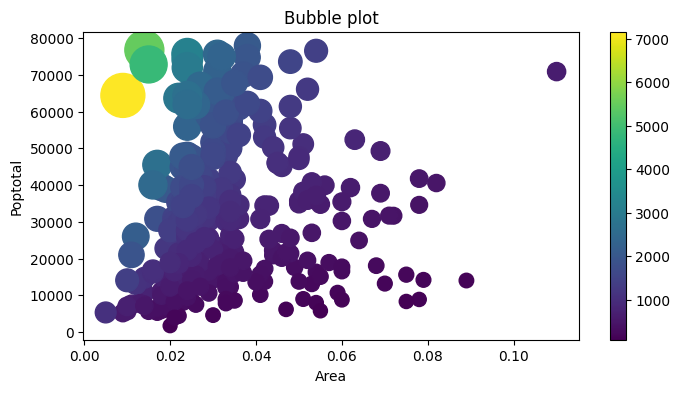

In [120]:
# Scatterplot with varying size and color of points
fig = plt.figure(figsize=(8, 4))

plt.scatter("area", "poptotal", data=midwest, s="dot_size", c="popdensity")
plt.title("Bubble plot")
plt.xlabel("Area")
plt.ylabel("Poptotal")
plt.colorbar()
plt.show()

# Labels and legends

Legends for curves in a figure can be added in two ways. One method is to use the `legend` method of the axis object and pass a list/tuple of legend texts for the previously defined curves:

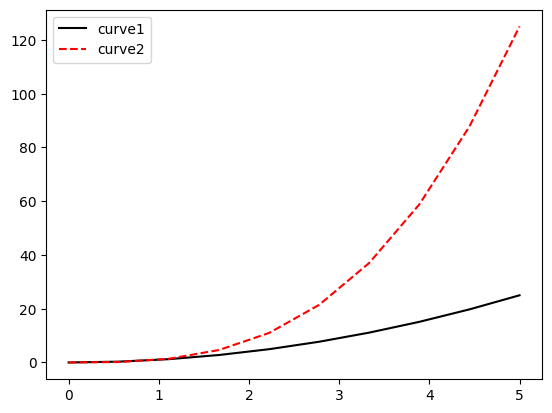

In [121]:
x = np.linspace(0, 5, 10)

fig = plt.figure()
ax = fig.add_subplot()
ax.plot(x, x**2, color="black")
ax.plot(x, x**3, color="red", linestyle="dashed")
ax.legend(["curve1", "curve2"])
plt.show()

This method is somewhat prone to errors and unflexible if curves are added to or removed from the figure (resulting in a wrongly labelled curve).

A better method is to use the `label="label text"` keyword argument when plots or other objects are added to the figure, and then using the `legend` method without arguments to add the legend to the figure:

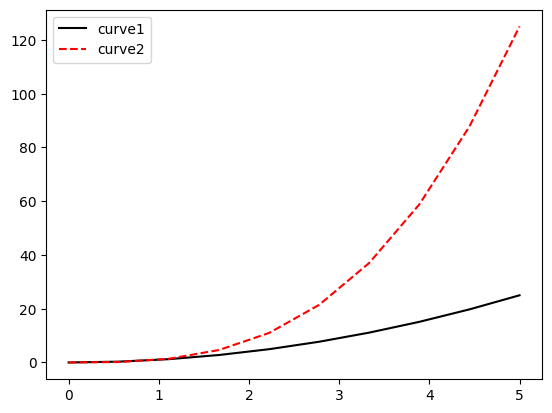

In [122]:
fig, ax = plt.subplots()

ax.plot(x, x**2, color="black", label="curve1")
ax.plot(x, x**3, color="red", linestyle="dashed", label="curve2")
ax.legend()
plt.show()

The advantage with this method is that if curves are added or removed from the figure, the legend is automatically updated accordingly.

The `legend` function takes an optional keyword argument `loc` that can be used to specify where in the figure the legend is to be drawn. The allowed values of `loc` are numerical codes for the various places the legend can be drawn. See http://matplotlib.org/users/legend_guide.html#legend-location for details. Some of the most common `loc` values are:

```
ax.legend(loc=0) # (default) let matplotlib decide the optimal location
ax.legend(loc=1) # upper right corner
ax.legend(loc=2) # upper left corner
ax.legend(loc=3) # lower left corner
ax.legend(loc=4) # lower right corner
# .. many more options are available
```

### From video
*Customization options*


### Histograms


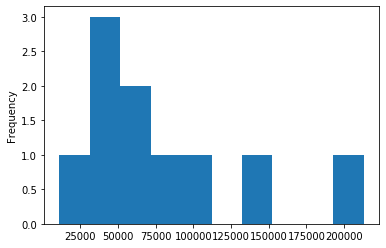

In [ ]:
car_sales["Odometer (KM)"].plot.hist();

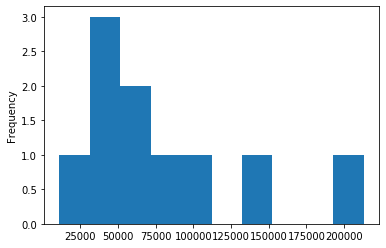

In [ ]:
car_sales["Odometer (KM)"].plot(kind="hist");

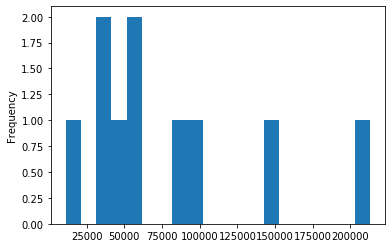

In [ ]:
# Default number of bins is 10 
car_sales["Odometer (KM)"].plot.hist(bins=20);

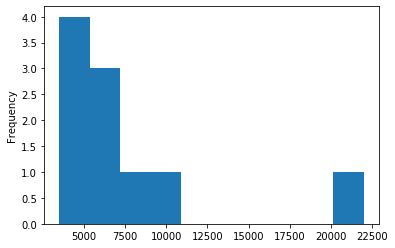

In [ ]:
car_sales["Price"].plot.hist(bins=10);

In [ ]:
# Let's try with another dataset
heart_disease = pd.read_csv("../data/heart-disease.csv")
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


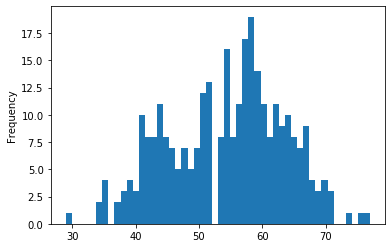

In [ ]:
heart_disease["age"].plot.hist(bins=50);

### Subplots
* Concept
* DataFrame

In [ ]:
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


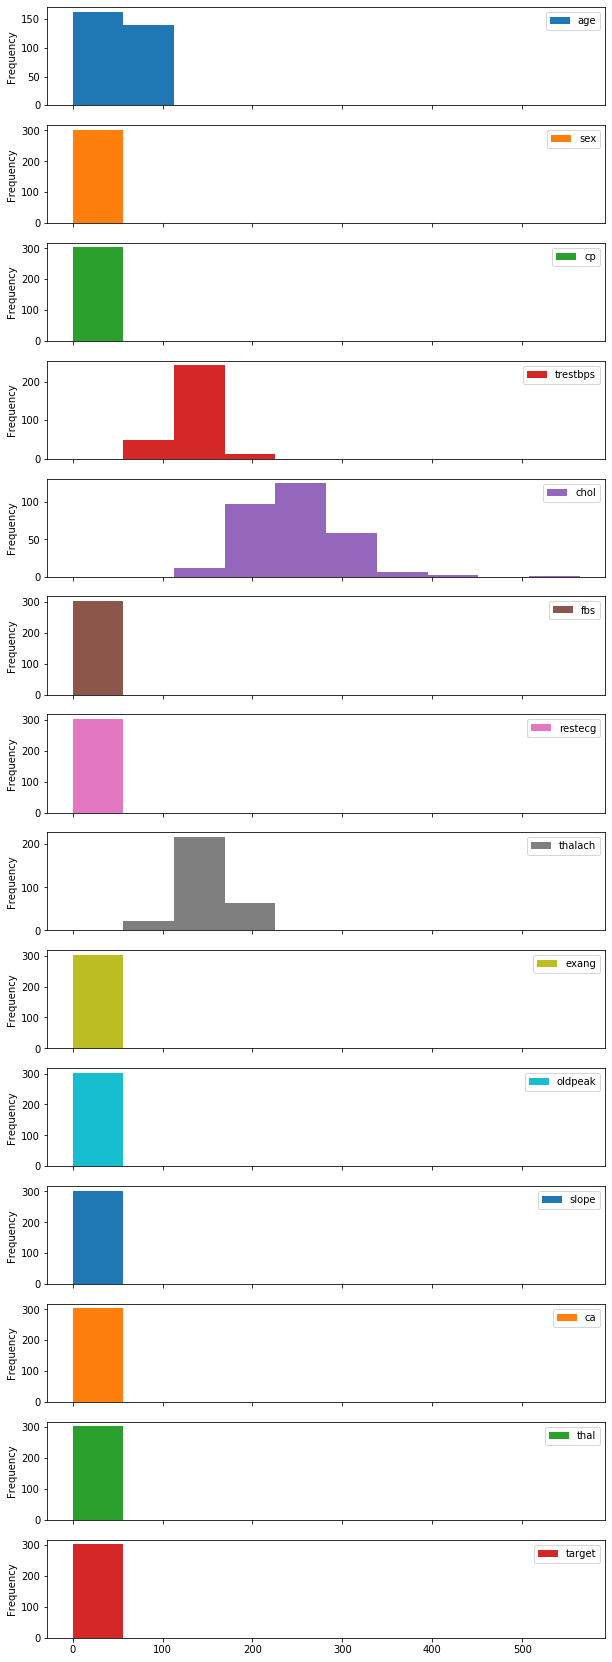

In [ ]:
heart_disease.plot.hist(figsize=(10, 30), subplots=True);

## 4. Plotting with pandas using the OO method 

For more complicated plots, you'll want to use the OO method.

In [ ]:
# Perform data analysis on patients over 50
over_50 = heart_disease[heart_disease["age"] > 50]
over_50

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,59,1,0,164,176,1,0,90,0,1.0,1,2,1,0
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


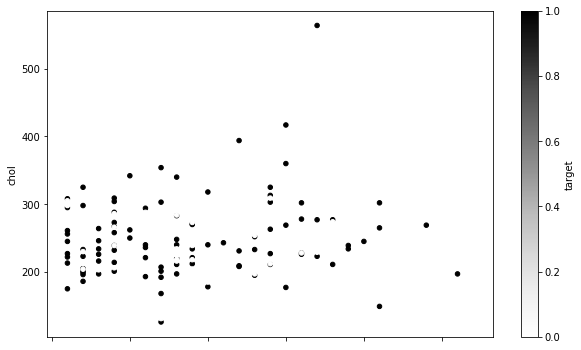

In [ ]:
over_50.plot(kind='scatter', 
             x='age', 
             y='chol', 
             c='target', 
             figsize=(10, 6));

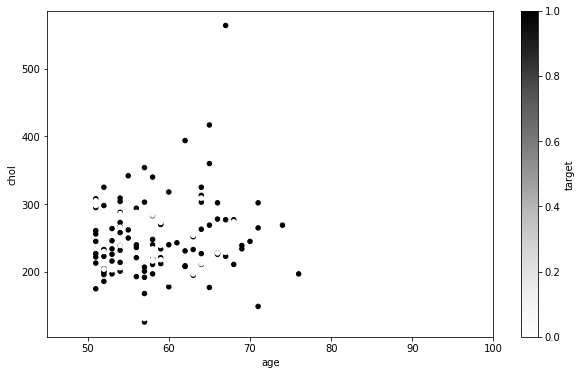

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
over_50.plot(kind='scatter', 
             x="age", 
             y="chol", 
             c='target', 
             ax=ax);
ax.set_xlim([45, 100]);

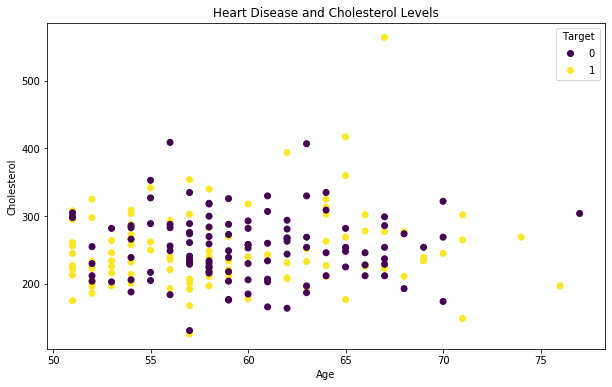

In [ ]:
# Make a bit more of a complicated plot

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the data
scatter = ax.scatter(over_50["age"], 
                     over_50["chol"], 
                     c=over_50["target"])

# Customize the plot
ax.set(title="Heart Disease and Cholesterol Levels",
       xlabel="Age",
       ylabel="Cholesterol");
ax.legend(*scatter.legend_elements(), title="Target");

What if we wanted a horizontal line going across with the mean of `heart_disease["chol"]`?

https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.axes.Axes.axhline.html

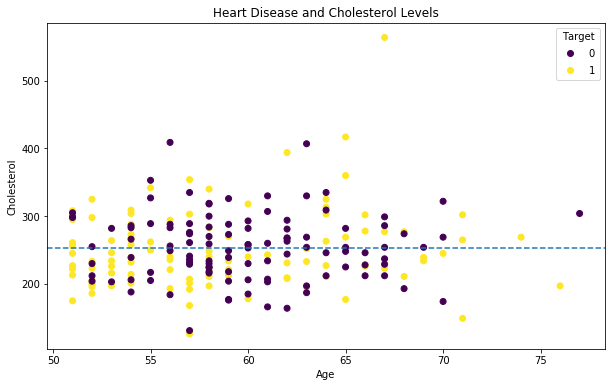

In [ ]:
# Make a bit more of a complicated plot

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the data
scatter = ax.scatter(over_50["age"], 
                     over_50["chol"], 
                     c=over_50["target"])

# Customize the plot
ax.set(title="Heart Disease and Cholesterol Levels",
       xlabel="Age",
       ylabel="Cholesterol");
ax.legend(*scatter.legend_elements(), title="Target")

# Add a meanline
ax.axhline(over_50["chol"].mean(),
           linestyle="--");

### Adding another plot to existing styled one

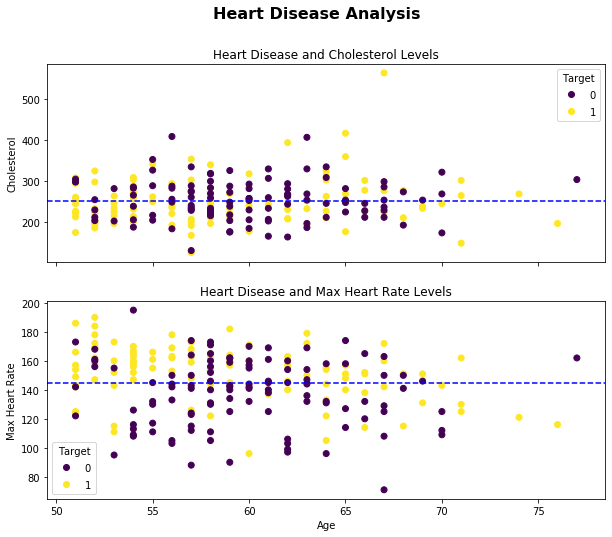

In [ ]:
# Setup plot (2 rows, 1 column)
fig, (ax0, ax1) = plt.subplots(nrows=2, # 2 rows
                               ncols=1, 
                               sharex=True, 
                               figsize=(10, 8))

# Add data for ax0
scatter = ax0.scatter(over_50["age"], 
                      over_50["chol"], 
                      c=over_50["target"])
# Customize ax0
ax0.set(title="Heart Disease and Cholesterol Levels",
        ylabel="Cholesterol")
ax0.legend(*scatter.legend_elements(), title="Target")

# Setup a mean line
ax0.axhline(y=over_50["chol"].mean(), 
            color='b', 
            linestyle='--', 
            label="Average")


# Add data for ax1
scatter = ax1.scatter(over_50["age"], 
                      over_50["thalach"], 
                      c=over_50["target"])

# Customize ax1
ax1.set(title="Heart Disease and Max Heart Rate Levels",
        xlabel="Age",
        ylabel="Max Heart Rate")
ax1.legend(*scatter.legend_elements(), title="Target")

# Setup a mean line
ax1.axhline(y=over_50["thalach"].mean(), 
            color='b', 
            linestyle='--', 
            label="Average")

# Title the figure
fig.suptitle('Heart Disease Analysis', fontsize=16, fontweight='bold');

## 5. Customizing your plots

This is where Matplotlib starts to feel powerful.

In this section we will work through several layers of customization:

- styles
- titles and axis labels
- legends
- colormaps
- axis limits
- ticks and tick labels


### Style

### From kopie
*Colors and line styles*


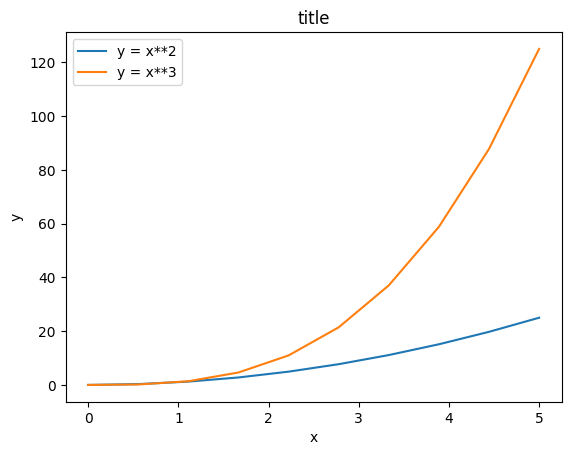

In [123]:
fig, ax = plt.subplots()

ax.plot(x, x**2, label="y = x**2")
ax.plot(x, x**3, label="y = x**3")
ax.legend(loc=2) # upper left corner
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('title')

plt.show()

# Formatting: LaTeX, rcParams, plot styles


Matplotlib has great support for LaTeX. All we need to do is to use dollar signs to encapsulate LaTeX equations in any text (legend, title, label, etc.). For example, `"$y=x^3$"`.

But here we can run into a slightly subtle problem with LaTeX code and Python text strings. In LaTeX, we frequently use the backslash in commands, for example `\alpha` to produce the symbol $\alpha$. But the backslash already has a meaning in Python strings (the escape code character). To avoid Python messing up our latex code, we need to use "raw" text strings. Raw text strings are prepended with an '`r`', like `r"\alpha"` or `r'\alpha'` instead of `"\alpha"` or `'\alpha'`.

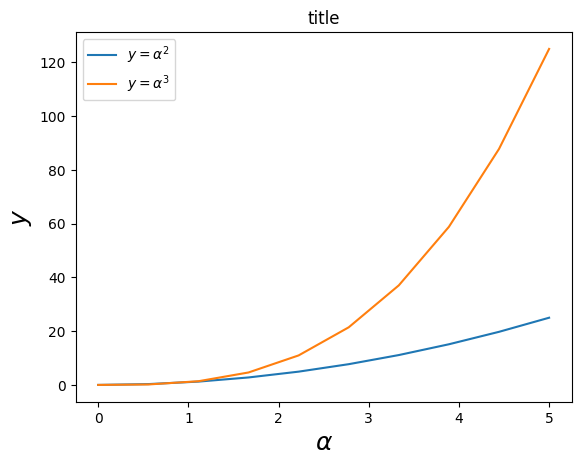

In [124]:
fig, ax = plt.subplots()

ax.plot(x, x**2, label=r"$y = \alpha^2$")
ax.plot(x, x**3, label=r"$y = \alpha^3$")
ax.legend(loc=2) # upper left corner
ax.set_xlabel(r'$\alpha$', fontsize=18)
ax.set_ylabel(r'$y$', fontsize=18)
ax.set_title('title')

plt.show()

The look and feel of various components of a matplotlib plot can be set globally using *rcParams*.

The complete list of rcParams is very exhaustive: see the [help page](https://matplotlib.org/stable/api/matplotlib_configuration_api.html#matplotlib.rcParams) for the full list and explanation.
You can also view it by typing:

In [125]:
import matplotlib as mpl
mpl.rc_params()

RcParams({'_internal.classic_mode': False,
          'agg.path.chunksize': 0,
          'animation.bitrate': -1,
          'animation.codec': 'h264',
          'animation.convert_args': ['-layers', 'OptimizePlus'],
          'animation.convert_path': 'convert',
          'animation.embed_limit': 20.0,
          'animation.ffmpeg_args': [],
          'animation.ffmpeg_path': 'ffmpeg',
          'animation.frame_format': 'png',
          'animation.html': 'none',
          'animation.writer': 'ffmpeg',
          'axes.autolimit_mode': 'data',
          'axes.axisbelow': 'line',
          'axes.edgecolor': 'black',
          'axes.facecolor': 'white',
          'axes.formatter.limits': [-5, 6],
          'axes.formatter.min_exponent': 0,
          'axes.formatter.offset_threshold': 4,
          'axes.formatter.use_locale': False,
          'axes.formatter.use_mathtext': False,
          'axes.formatter.useoffset': True,
          'axes.grid': False,
          'axes.grid.axis': 'both',
   

You can dynamically adjust the params you'd like to change by updating it at runtime.
For example, the below snippet adjusts the font by setting it to ['stix'](https://www.stixfonts.org/), which is a good choice since it looks great on plots.

In [126]:
mpl.rcParams.update({'font.size': 18,
                     'font.family': 'STIXGeneral',
                     'mathtext.fontset': 'stix'})

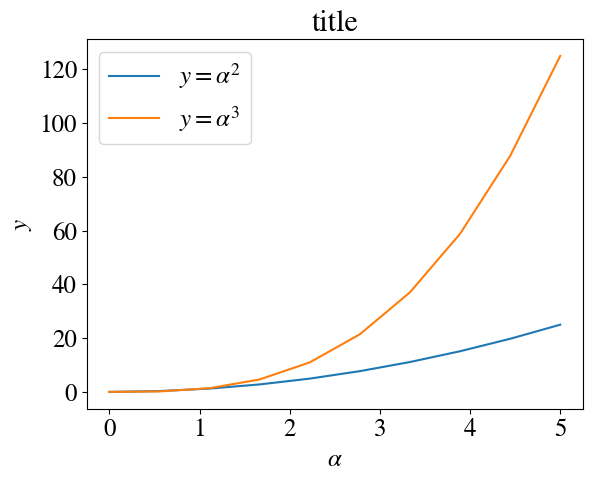

In [127]:
fig, ax = plt.subplots()

ax.plot(x, x**2, label=r"$y = \alpha^2$")
ax.plot(x, x**3, label=r"$y = \alpha^3$")
ax.legend(loc=2) # upper left corner
ax.set_xlabel(r'$\alpha$', fontsize=18)
ax.set_ylabel(r'$y$', fontsize=18)
ax.set_title('title')

plt.show()

After modifying a plot, you can rollback the rcParams to default setting using:

In [128]:
mpl.rcParams.update(mpl.rcParamsDefault)  # reset to defaults

This looks more convenient than R's way to deal with graphical parameters (`op <- par(mfrow=(2,1); ...; par(op))`)

Matplotlib comes with **pre-built styles** that you can browse by typing:

In [129]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

Notice `fivethirtyeight`, and `ggplot`.

`seaborn` is called after another high-level plotting library that is especially useful if your input is in a Pandas dataframe. Note however that the seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn.

Let's play with some of the pre-built styles by creating a function that takes a style name as input and produces a plot with sine and cosine waves.

---

# Section 8: Advanced Customization

**Description:** Ticks, styles, themes, rcParams, and annotations

**Estimated Time:** 25-30 minutes

---


### From fundamentals
*Comprehensive ticks guide*


<!-- Translation needed from German -->

## 6. Ticks verstehen und anpassen

### Was sind Ticks?

**Ticks** sind die **kleinen Markierungen** auf den Achsen, die zeigen, wo bestimmte Werte liegen.

```
Y-Achse
  |
100 ←  Tick (Markierung + Label)
  |
 75 ←  Tick
  |
 50 ←  Tick
  |
 25 ←  Tick
  |
  0 ←  Tick
  +----------→ X-Achse
    0  25  50  75  100
    ↑   ↑   ↑   ↑   ↑
    Ticks (Markierungen + Labels)
```

Jeder Tick besteht aus zwei Teilen:
1. **Tick-Position**: Wo die Markierung auf der Achse ist (z.B. bei 0, 25, 50)
2. **Tick-Label**: Der Text, der neben der Markierung steht (z.B. "0", "25", "50")

### Warum sind Ticks wichtig?

- Sie helfen dem Leser, **Werte abzulesen**
- Sie geben **Orientierung** im Plot
- Sie können **Einheiten** zeigen (%, €, km, etc.)
- Sie beeinflussen die **Lesbarkeit** des Plots

Gesetzte Ticks:
X-Ticks: [22 23 24 25 26 27 28 29 30 31 32]
Y-Ticks: [0.   0.25 0.5  0.75 1.  ]

Formatierte Y-Labels:
['0%', '25%', '50%', '75%', '100%']


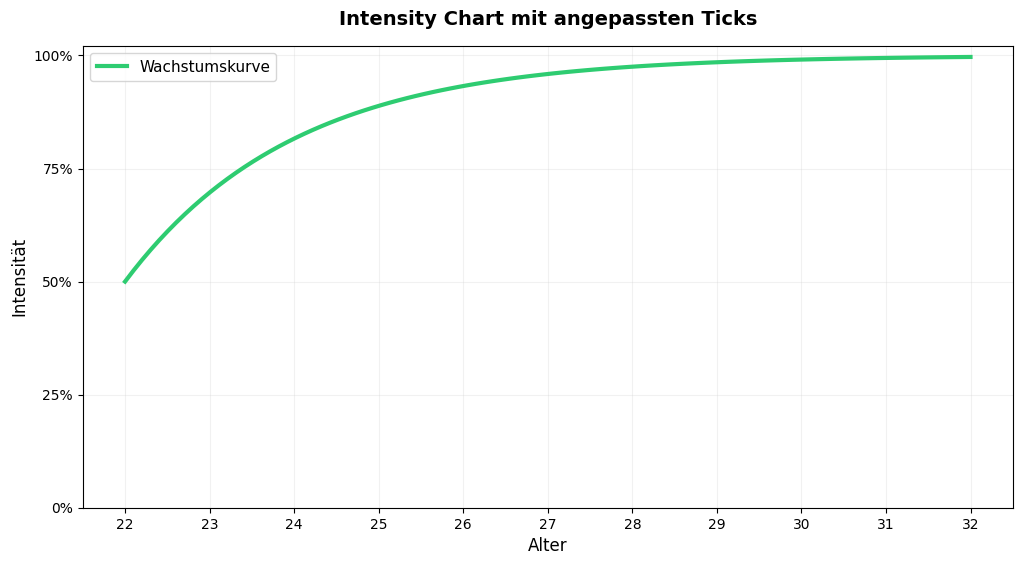


🎉 Perfekt! Du hast gelernt:
   ✅ Was Ticks sind (Markierungen auf Achsen)
   ✅ Wie man sie manuell setzt (set_xticks, set_yticks)
   ✅ Wie man sie mit linspace erstellt (gleichmäßig verteilt)
   ✅ Wie man Tick-Labels anpasst (Prozent, Euro, etc.)

   Du kannst jetzt professionelle Plots mit perfekten Ticks erstellen! 🚀


In [8]:
# Vollständiges Beispiel: Intensity Chart

# 1. Daten erstellen
x = np.linspace(22, 32, 100)
y = 0.5 + 0.5 * (1 - np.exp(-0.5 * (x - 22)))

# 2. Figure + Axes erstellen
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# 3. Plotten
ax.plot(x, y, color='#2ecc71', linewidth=3, label='Wachstumskurve')

# 4. Ticks mit linspace setzen
x_ticks = np.arange(22, 33, 1)  # Jedes Jahr von 22 bis 32
y_ticks = np.linspace(0, 1, 5)  # 5 gleichmäßige Ticks von 0 bis 1
ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)

print("Gesetzte Ticks:")
print(f"X-Ticks: {x_ticks}")
print(f"Y-Ticks: {y_ticks}\n")

# 5. Tick-Labels als Prozent formatieren
ax.set_yticklabels([f'{int(t*100)}%' for t in y_ticks])

print("Formatierte Y-Labels:")
print([f'{int(t*100)}%' for t in y_ticks])

# 6. Styling
ax.set_xlabel('Alter', fontsize=12)
ax.set_ylabel('Intensität', fontsize=12)
ax.set_title('Intensity Chart mit angepassten Ticks', fontsize=14, weight='bold', pad=15)
ax.grid(True, alpha=0.3, color='#d3d3d3')
ax.legend(fontsize=11)

# 7. Anzeigen
plt.show()

print("\n🎉 Perfekt! Du hast gelernt:")
print("   ✅ Was Ticks sind (Markierungen auf Achsen)")
print("   ✅ Wie man sie manuell setzt (set_xticks, set_yticks)")
print("   ✅ Wie man sie mit linspace erstellt (gleichmäßig verteilt)")
print("   ✅ Wie man Tick-Labels anpasst (Prozent, Euro, etc.)")
print("\n   Du kannst jetzt professionelle Plots mit perfekten Ticks erstellen! 🚀")

<!-- Translation needed from German -->

## 6.1 Automatische Ticks (Standard)

Matplotlib setzt **automatisch** Ticks basierend auf deinen Daten:

```python
ax.plot([1, 2, 3], [10, 20, 30])
# Matplotlib wählt automatisch sinnvolle Tick-Positionen
```

#### Wie entscheidet Matplotlib?

1. Schaut sich die **Min/Max-Werte** deiner Daten an
2. Wählt **runde Zahlen** (0, 5, 10, 20, 50, 100, etc.)
3. Versucht **5-10 Ticks** zu setzen (nicht zu viele, nicht zu wenige)
4. Passt sich an die **Größe des Plots** an

<!-- Translation needed from German -->

### 6.2 Ticks manuell setzen

Manchmal möchtest du die Ticks **selbst bestimmen**:

```python
# X-Achse Ticks setzen
ax.set_xticks([0, 1, 2, 3, 4, 5])

# Y-Achse Ticks setzen
ax.set_yticks([0, 25, 50, 75, 100])
```

#### Wann solltest du Ticks manuell setzen?

- Wenn du **spezifische Werte** hervorheben willst
- Wenn die automatischen Ticks **nicht passen**
- Wenn du **gleichmäßige Abstände** brauchst
- Wenn du **bestimmte Einheiten** zeigen willst (z.B. jedes Jahr, jeden Monat)

Automatische Ticks:
X: [-2.  0.  2.  4.  6.  8. 10. 12.]
Y: [-20.   0.  20.  40.  60.  80. 100. 120.]

Manuelle Ticks:
X: [ 0  2  4  6 10]
Y: [  0  20  40  60 100]


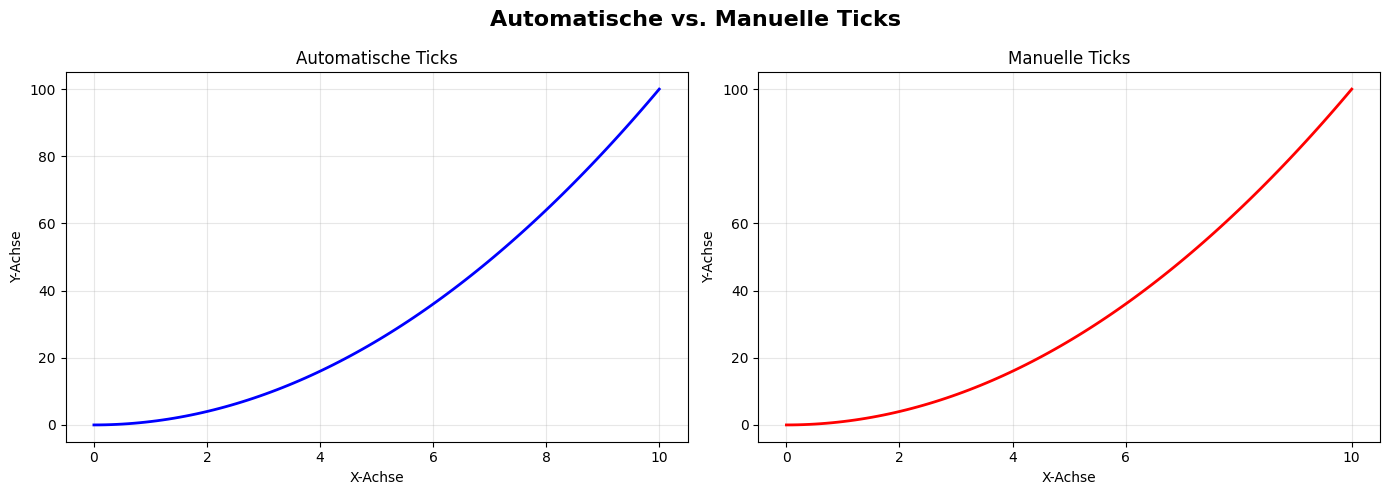


💡 Mit set_xticks() und set_yticks() kannst du Ticks manuell setzen!


In [23]:
# Beispiel: Ticks manuell setzen

x = np.linspace(0, 10, 100)
y = x ** 2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Automatische vs. Manuelle Ticks', fontsize=16, weight='bold')

# Links: Automatische Ticks
ax1.plot(x, y, 'b-', linewidth=2)
ax1.set_title('Automatische Ticks', fontsize=12)
ax1.set_xlabel('X-Achse')
ax1.set_ylabel('Y-Achse')
ax1.grid(True, alpha=0.3)

print("Automatische Ticks:")
print(f"X: {ax1.get_xticks()}")
print(f"Y: {ax1.get_yticks()}\n")

# Rechts: Manuelle Ticks
ax2.plot(x, y, 'r-', linewidth=2)
ax2.set_xticks([0, 2, 4, 6, 10])  # ← Manuell gesetzt!
ax2.set_yticks([0, 20, 40, 60, 100])  # ← Manuell gesetzt!
ax2.set_title('Manuelle Ticks', fontsize=12)
ax2.set_xlabel('X-Achse')
ax2.set_ylabel('Y-Achse')
ax2.grid(True, alpha=0.3)

print("Manuelle Ticks:")
print(f"X: {ax2.get_xticks()}")
print(f"Y: {ax2.get_yticks()}")

plt.tight_layout()
plt.show()

print("\n💡 Mit set_xticks() und set_yticks() kannst du Ticks manuell setzen!")

<!-- Translation needed from German -->

### 6.3 Ticks mit `np.linspace()` erstellen

**Das ist der Trick!** Du kannst `np.linspace()` nutzen, um **gleichmäßig verteilte Ticks** zu erstellen.

#### Warum `linspace` für Ticks?

```python
# Problem: Ich will 5 gleichmäßige Ticks von 0 bis 100
# Lösung mit linspace:
ticks = np.linspace(0, 100, 5)  # [0, 25, 50, 75, 100]
ax.set_yticks(ticks)
```

#### Die Formel:

```python
np.linspace(start, stop, num)
#           ↑      ↑     ↑
#           |      |     Anzahl der Punkte
#           |      Endwert (inklusive!)
#           Startwert
```

#### Beispiele:

```python
# 5 Ticks von 0 bis 100
np.linspace(0, 100, 5)  # [0, 25, 50, 75, 100]

# 11 Ticks von 0 bis 10 (jede ganze Zahl)
np.linspace(0, 10, 11)  # [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# 6 Ticks von 0 bis 1 (für Prozent)
np.linspace(0, 1, 6)  # [0, 0.2, 0.4, 0.6, 0.8, 1.0]
```

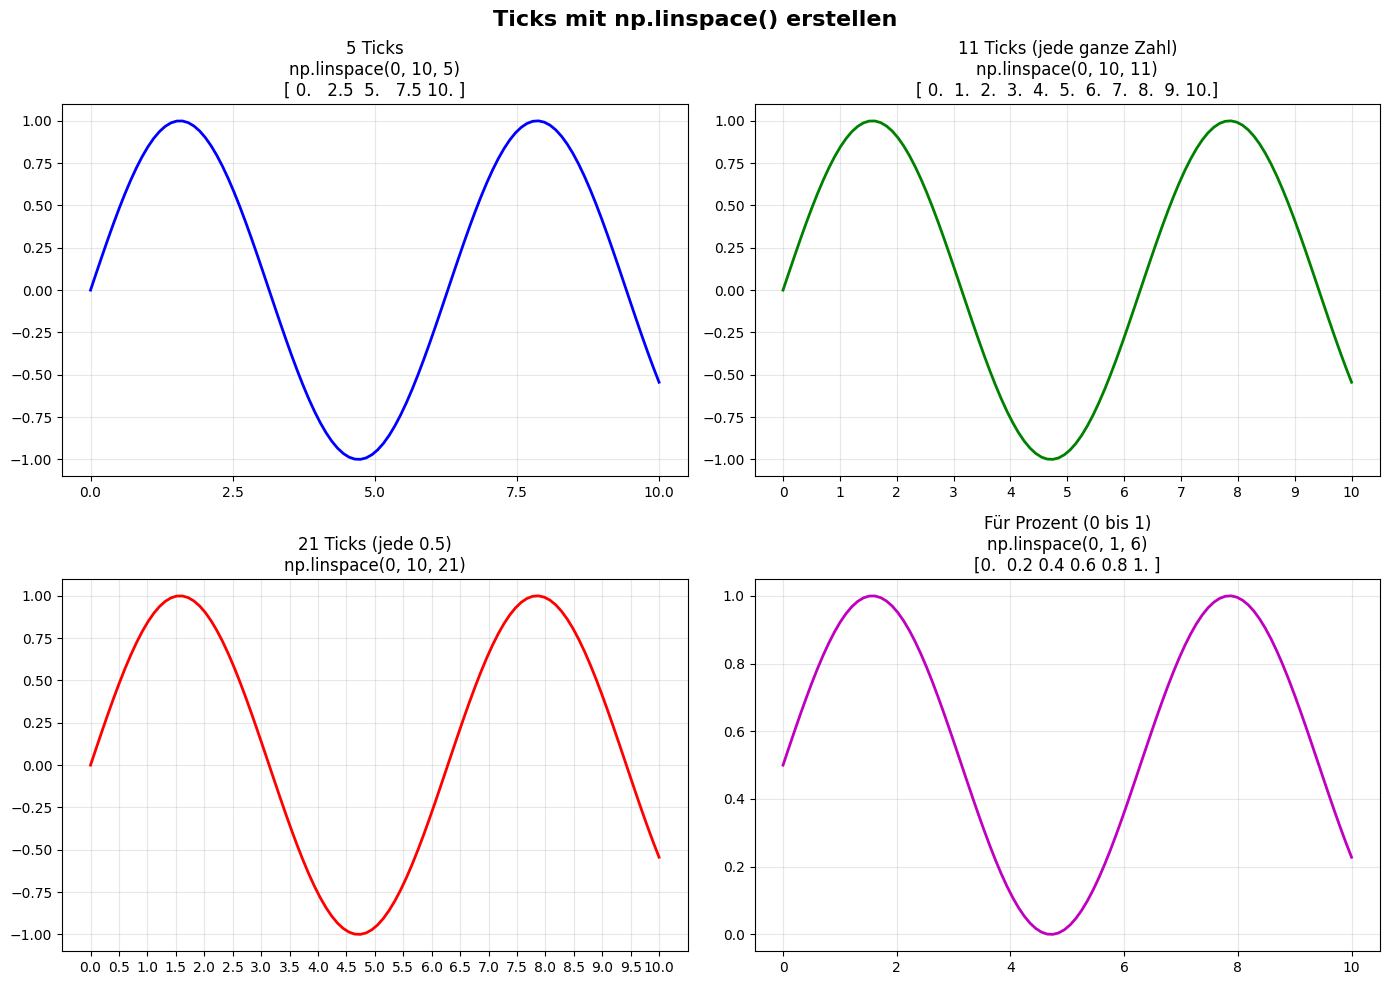


💡 np.linspace() ist perfekt für gleichmäßig verteilte Ticks!
   - np.linspace(0, 100, 5) → [0, 25, 50, 75, 100]
   - np.linspace(0, 10, 11) → [0, 1, 2, ..., 10]
   - np.linspace(0, 1, 6) → [0, 0.2, 0.4, 0.6, 0.8, 1.0]


In [10]:
# Beispiel: Ticks mit linspace erstellen

x = np.linspace(0, 10, 100)
y = np.sin(x)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Ticks mit np.linspace() erstellen', fontsize=16, weight='bold')

# 1. Wenige Ticks (5 Stück)
axes[0, 0].plot(x, y, 'b-', linewidth=2)
x_ticks_5 = np.linspace(0, 10, 5)
axes[0, 0].set_xticks(x_ticks_5)
axes[0, 0].set_title(f'5 Ticks\nnp.linspace(0, 10, 5)\n{x_ticks_5}')
axes[0, 0].grid(True, alpha=0.3)

# 2. Mittlere Anzahl (11 Ticks)
axes[0, 1].plot(x, y, 'g-', linewidth=2)
x_ticks_11 = np.linspace(0, 10, 11)
axes[0, 1].set_xticks(x_ticks_11)
axes[0, 1].set_title(f'11 Ticks (jede ganze Zahl)\nnp.linspace(0, 10, 11)\n{x_ticks_11}')
axes[0, 1].grid(True, alpha=0.3)

# 3. Viele Ticks (21 Stück)
axes[1, 0].plot(x, y, 'r-', linewidth=2)
x_ticks_21 = np.linspace(0, 10, 21)
axes[1, 0].set_xticks(x_ticks_21)
axes[1, 0].set_title(f'21 Ticks (jede 0.5)\nnp.linspace(0, 10, 21)')
axes[1, 0].grid(True, alpha=0.3)

# 4. Für Prozent (6 Ticks von 0 bis 1)
axes[1, 1].plot(x, (y + 1) / 2, 'm-', linewidth=2)  # Normalisiert auf 0-1
y_ticks_percent = np.linspace(0, 1, 6)
axes[1, 1].set_yticks(y_ticks_percent)
axes[1, 1].set_title(f'Für Prozent (0 bis 1)\nnp.linspace(0, 1, 6)\n{y_ticks_percent}')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 np.linspace() ist perfekt für gleichmäßig verteilte Ticks!")
print("   - np.linspace(0, 100, 5) → [0, 25, 50, 75, 100]")
print("   - np.linspace(0, 10, 11) → [0, 1, 2, ..., 10]")
print("   - np.linspace(0, 1, 6) → [0, 0.2, 0.4, 0.6, 0.8, 1.0]")

<!-- Translation needed from German -->

### 6.4 Tick-Labels anpassen

**Tick-Labels** sind die **Texte** neben den Ticks. Du kannst sie anpassen, um:
- **Prozent** anzuzeigen (0%, 25%, 50%)
- **Währungen** zu zeigen (0€, 50€, 100€)
- **Einheiten** hinzuzufügen (0 km, 50 km, 100 km)
- **Eigene Texte** zu verwenden ("Niedrig", "Mittel", "Hoch")

#### Methode 1: Mit Liste

```python
# 1. Ticks setzen
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])

# 2. Labels anpassen
ax.set_yticklabels(['0%', '25%', '50%', '75%', '100%'])
```

#### Methode 2: Mit List Comprehension

```python
ticks = np.linspace(0, 1, 5)
ax.set_yticks(ticks)
ax.set_yticklabels([f'{int(t*100)}%' for t in ticks])
```

#### Wichtig:

- Die **Anzahl der Labels** muss mit der **Anzahl der Ticks** übereinstimmen!
- Erst `set_xticks()`, dann `set_xticklabels()`

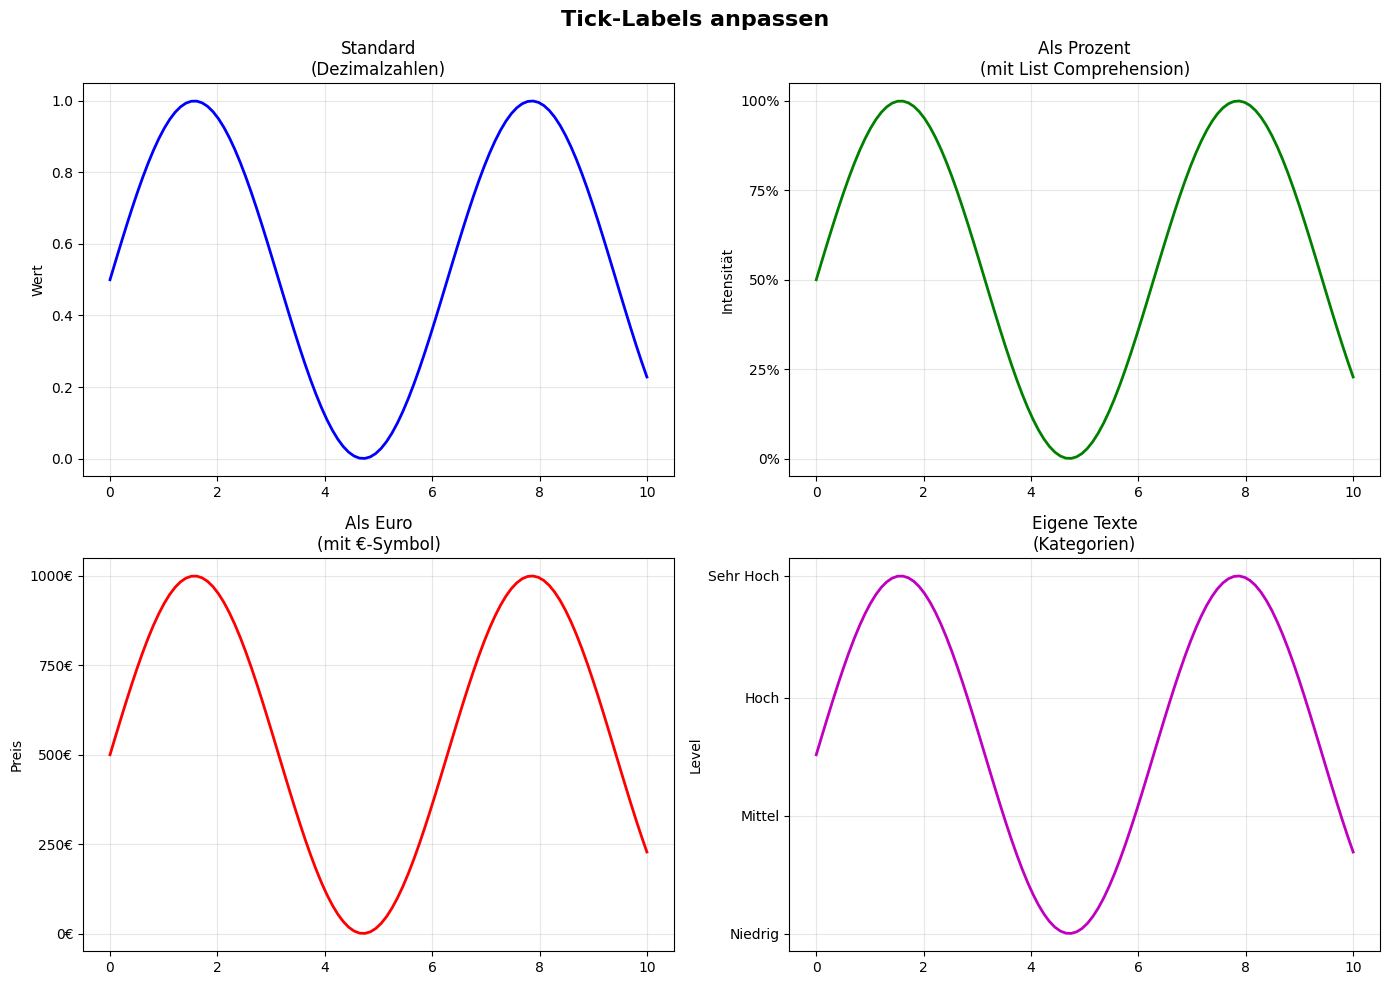


💡 Tick-Labels anpassen:
   1. Ticks setzen: ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
   2. Labels ändern: ax.set_yticklabels(['0%', '25%', '50%', '75%', '100%'])
   3. Oder mit List Comprehension: [f'{int(t*100)}%' for t in ticks]


In [11]:
# Beispiel: Tick-Labels anpassen

x = np.linspace(0, 10, 100)
y = np.sin(x) * 0.5 + 0.5  # Werte zwischen 0 und 1

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Tick-Labels anpassen', fontsize=16, weight='bold')

# 1. Standard (Dezimalzahlen)
axes[0, 0].plot(x, y, 'b-', linewidth=2)
axes[0, 0].set_title('Standard\n(Dezimalzahlen)', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylabel('Wert')

# 2. Als Prozent (mit List Comprehension)
axes[0, 1].plot(x, y, 'g-', linewidth=2)
y_ticks = np.linspace(0, 1, 5)
axes[0, 1].set_yticks(y_ticks)
axes[0, 1].set_yticklabels([f'{int(t*100)}%' for t in y_ticks])
axes[0, 1].set_title('Als Prozent\n(mit List Comprehension)', fontsize=12)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylabel('Intensität')

# 3. Als Euro
axes[1, 0].plot(x, y * 1000, 'r-', linewidth=2)
y_ticks_euro = np.linspace(0, 1000, 5)
axes[1, 0].set_yticks(y_ticks_euro)
axes[1, 0].set_yticklabels([f'{int(t)}€' for t in y_ticks_euro])
axes[1, 0].set_title('Als Euro\n(mit €-Symbol)', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylabel('Preis')

# 4. Eigene Texte
axes[1, 1].plot(x, y, 'm-', linewidth=2)
axes[1, 1].set_yticks([0, 0.33, 0.66, 1.0])
axes[1, 1].set_yticklabels(['Niedrig', 'Mittel', 'Hoch', 'Sehr Hoch'])
axes[1, 1].set_title('Eigene Texte\n(Kategorien)', fontsize=12)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylabel('Level')

plt.tight_layout()
plt.show()

print("\n💡 Tick-Labels anpassen:")
print("   1. Ticks setzen: ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])")
print("   2. Labels ändern: ax.set_yticklabels(['0%', '25%', '50%', '75%', '100%'])")
print("   3. Oder mit List Comprehension: [f'{int(t*100)}%' for t in ticks]")

### 6.5 Praktisches Beispiel: Intensity Chart mit Ticks

Jetzt kombinieren wir alles, was wir gelernt haben, um einen professionellen Plot zu erstellen:

1. **Ticks mit `linspace` erstellen**
2. **Tick-Labels als Prozent formatieren**
3. **Styling anpassen**

<!-- Translation needed from German -->

### 6.6 Zusammenfassung: Ticks

#### Was sind Ticks?
- **Markierungen** auf den Achsen
- Bestehen aus **Position** (wo) und **Label** (was steht da)
- Helfen beim **Ablesen** von Werten

#### Automatische Ticks:
```python
# Matplotlib setzt automatisch Ticks
ax.plot(x, y)
# Ticks werden basierend auf Daten gewählt
```

#### Manuelle Ticks:
```python
# Mit Liste
ax.set_xticks([0, 1, 2, 3, 4, 5])
ax.set_yticks([0, 25, 50, 75, 100])
```

#### Ticks mit linspace:
```python
# Gleichmäßig verteilte Ticks
x_ticks = np.linspace(0, 10, 11)  # 0, 1, 2, ..., 10
y_ticks = np.linspace(0, 1, 5)    # 0, 0.25, 0.5, 0.75, 1.0
ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)
```

#### Tick-Labels anpassen:
```python
# Methode 1: Mit Liste
ax.set_yticklabels(['0%', '25%', '50%', '75%', '100%'])

# Methode 2: Mit List Comprehension
ax.set_yticklabels([f'{int(t*100)}%' for t in y_ticks])
```

#### Der typische Workflow:
```python
# 1. Ticks mit linspace erstellen
y_ticks = np.linspace(0, 1, 5)

# 2. Ticks setzen
ax.set_yticks(y_ticks)

# 3. Labels formatieren
ax.set_yticklabels([f'{int(t*100)}%' for t in y_ticks])
```

#### Wichtige Regeln:
- ✅ Erst `set_xticks()`, dann `set_xticklabels()`
- ✅ Anzahl Labels = Anzahl Ticks
- ✅ `linspace` für gleichmäßige Verteilung
- ✅ List Comprehension für dynamische Labels

### From kopie
*Formatting, rcParams, and styles*


In [130]:
# our custom function
def plot_sine_cosine_wave(style="ggplot"):
    mpl.rcParams.update(mpl.rcParamsDefault)
    plt.style.use(style)

    X = np.linspace(0, 2 * np.pi, 100)

    fig, ax = plt.subplots(figsize=(8, 4), dpi=100)
    ax.plot(X, np.sin(X))
    ax.plot(X, np.cos(X))
    ax.set(xlabel="x (radians)", ylabel="y", title=style)
    plt.show()
    mpl.rcParams.update(mpl.rcParamsDefault)

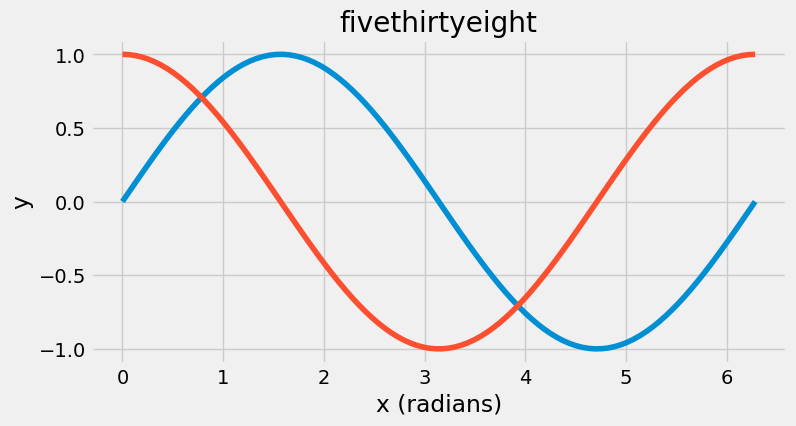

In [131]:
plot_sine_cosine_wave("fivethirtyeight")

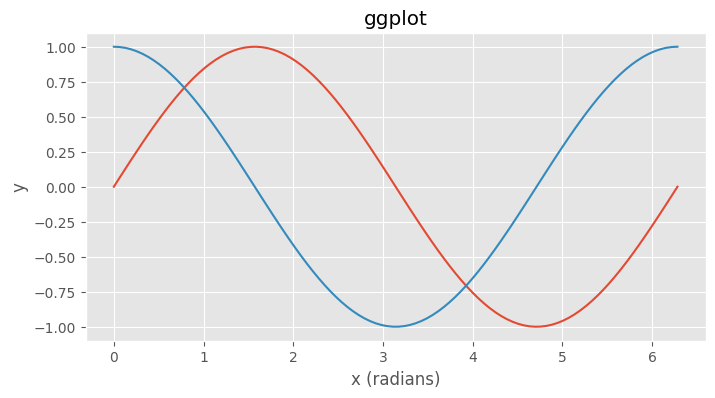

In [132]:
plot_sine_cosine_wave("ggplot")

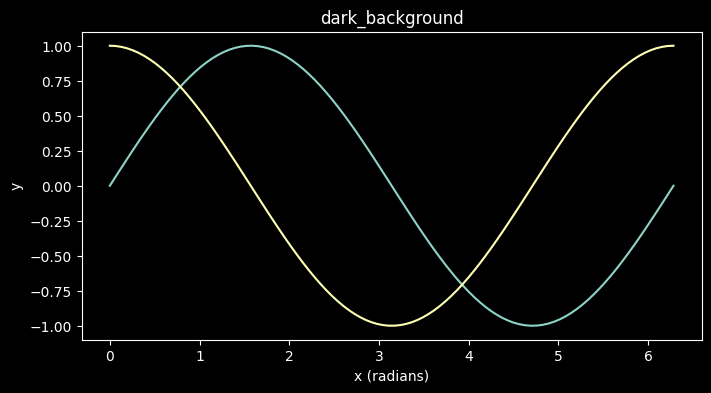

In [133]:
plot_sine_cosine_wave("dark_background")

# Colors, line widths, line types

We have already seen that we can define markers, colors, and line types with a `format` string such as `og-.` (green circles with dash-dot line).

You can also set these properties separately using appropriate keywork arguments inside `plot`.

## Colors

Define colors by their names or RGB hex codes and optionally provide an alpha value using the `color` and `alpha` keyword arguments:

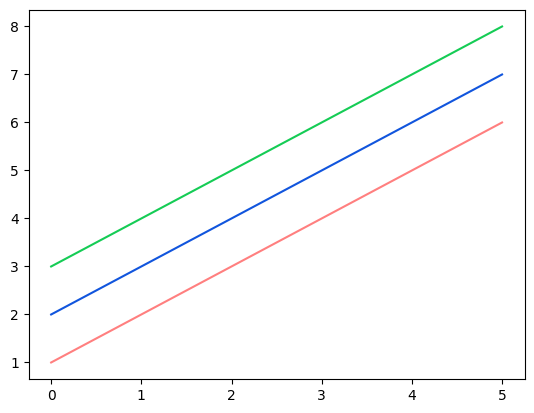

In [134]:
fig, ax = plt.subplots()

x = np.linspace(0, 5, 10)

ax.plot(x, x+1, color="red", alpha=0.5) # half-transparant red
ax.plot(x, x+2, color="#1155dd") # bluish color
ax.plot(x, x+3, color="#15cc55") # greenish color
plt.show()

Matplotlib also comes with **pre-built colors and palettes**. Type the following in your jupyter/python console to check out the available colors.

In [135]:
# View Colors
mpl.colors.CSS4_COLORS  # 148 colors

{'aliceblue': '#F0F8FF',
 'antiquewhite': '#FAEBD7',
 'aqua': '#00FFFF',
 'aquamarine': '#7FFFD4',
 'azure': '#F0FFFF',
 'beige': '#F5F5DC',
 'bisque': '#FFE4C4',
 'black': '#000000',
 'blanchedalmond': '#FFEBCD',
 'blue': '#0000FF',
 'blueviolet': '#8A2BE2',
 'brown': '#A52A2A',
 'burlywood': '#DEB887',
 'cadetblue': '#5F9EA0',
 'chartreuse': '#7FFF00',
 'chocolate': '#D2691E',
 'coral': '#FF7F50',
 'cornflowerblue': '#6495ED',
 'cornsilk': '#FFF8DC',
 'crimson': '#DC143C',
 'cyan': '#00FFFF',
 'darkblue': '#00008B',
 'darkcyan': '#008B8B',
 'darkgoldenrod': '#B8860B',
 'darkgray': '#A9A9A9',
 'darkgreen': '#006400',
 'darkgrey': '#A9A9A9',
 'darkkhaki': '#BDB76B',
 'darkmagenta': '#8B008B',
 'darkolivegreen': '#556B2F',
 'darkorange': '#FF8C00',
 'darkorchid': '#9932CC',
 'darkred': '#8B0000',
 'darksalmon': '#E9967A',
 'darkseagreen': '#8FBC8F',
 'darkslateblue': '#483D8B',
 'darkslategray': '#2F4F4F',
 'darkslategrey': '#2F4F4F',
 'darkturquoise': '#00CED1',
 'darkviolet': '#9400D3

In [136]:
mpl.colors.XKCD_COLORS  # 949 colors

{'xkcd:cloudy blue': '#acc2d9',
 'xkcd:dark pastel green': '#56ae57',
 'xkcd:dust': '#b2996e',
 'xkcd:electric lime': '#a8ff04',
 'xkcd:fresh green': '#69d84f',
 'xkcd:light eggplant': '#894585',
 'xkcd:nasty green': '#70b23f',
 'xkcd:really light blue': '#d4ffff',
 'xkcd:tea': '#65ab7c',
 'xkcd:warm purple': '#952e8f',
 'xkcd:yellowish tan': '#fcfc81',
 'xkcd:cement': '#a5a391',
 'xkcd:dark grass green': '#388004',
 'xkcd:dusty teal': '#4c9085',
 'xkcd:grey teal': '#5e9b8a',
 'xkcd:macaroni and cheese': '#efb435',
 'xkcd:pinkish tan': '#d99b82',
 'xkcd:spruce': '#0a5f38',
 'xkcd:strong blue': '#0c06f7',
 'xkcd:toxic green': '#61de2a',
 'xkcd:windows blue': '#3778bf',
 'xkcd:blue blue': '#2242c7',
 'xkcd:blue with a hint of purple': '#533cc6',
 'xkcd:booger': '#9bb53c',
 'xkcd:bright sea green': '#05ffa6',
 'xkcd:dark green blue': '#1f6357',
 'xkcd:deep turquoise': '#017374',
 'xkcd:green teal': '#0cb577',
 'xkcd:strong pink': '#ff0789',
 'xkcd:bland': '#afa88b',
 'xkcd:deep aqua': '#0

In [137]:
mpl.colors.BASE_COLORS  # 8 colors

{'b': (0, 0, 1),
 'g': (0, 0.5, 0),
 'r': (1, 0, 0),
 'c': (0, 0.75, 0.75),
 'm': (0.75, 0, 0.75),
 'y': (0.75, 0.75, 0),
 'k': (0, 0, 0),
 'w': (1, 1, 1)}

In [138]:
# View first 10 Palettes
dir(plt.cm)[:10]

['Accent',
 'Accent_r',
 'Blues',
 'Blues_r',
 'BrBG',
 'BrBG_r',
 'BuGn',
 'BuGn_r',
 'BuPu',
 'BuPu_r']

For more information and examples on Matplotlib's color palettes, have a look at the [official documentation](https://matplotlib.org/stable/gallery/color/colormap_reference.html).

---

# Section 9: Special Plot Types and Scales

**Description:** Logarithmic scales, scientific notation, advanced scatter plots

**Estimated Time:** 20-25 minutes

---


### From kopie
*Axis appearance, log scale, and advanced features*


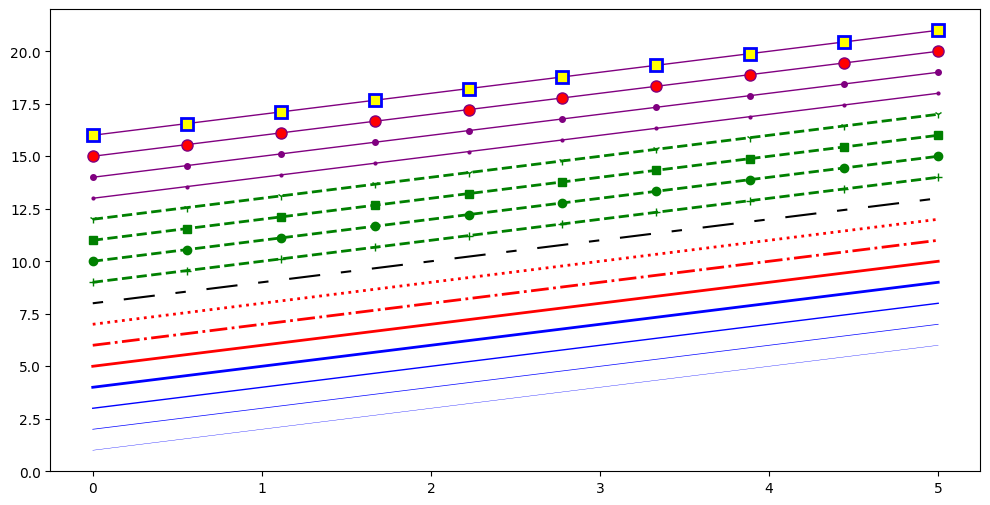

In [139]:
fig, ax = plt.subplots(figsize=(12,6))

ax.plot(x, x+1, color="blue", linewidth=0.25)
ax.plot(x, x+2, color="blue", linewidth=0.50)
ax.plot(x, x+3, color="blue", linewidth=1.00)
ax.plot(x, x+4, color="blue", linewidth=2.00)

# possible linestype options ‘-‘, ‘--’, ‘-.’, ‘:’, ‘steps’
ax.plot(x, x+5, color="red", lw=2, linestyle='-')
ax.plot(x, x+6, color="red", lw=2, ls='-.')
ax.plot(x, x+7, color="red", lw=2, ls=':')

# custom dash
line, = ax.plot(x, x+8, color="black", lw=1.50)
line.set_dashes([5, 10, 15, 10]) # format: line length, space length, ...

# possible marker symbols: marker = '+', 'o', '*', 's', ',', '.', '1', '2', '3', '4', ...
ax.plot(x, x+ 9, color="green", lw=2, ls='--', marker='+')
ax.plot(x, x+10, color="green", lw=2, ls='--', marker='o')
ax.plot(x, x+11, color="green", lw=2, ls='--', marker='s')
ax.plot(x, x+12, color="green", lw=2, ls='--', marker='1')

# marker size and color
ax.plot(x, x+13, color="purple", lw=1, ls='-', marker='o', markersize=2)
ax.plot(x, x+14, color="purple", lw=1, ls='-', marker='o', markersize=4)
ax.plot(x, x+15, color="purple", lw=1, ls='-', marker='o', markersize=8, markerfacecolor="red")
ax.plot(x, x+16, color="purple", lw=1, ls='-', marker='s', markersize=8,
        markerfacecolor="yellow", markeredgewidth=2, markeredgecolor="blue")

plt.show()

# Axis appearance

The appearance of the axes is an important aspect of a figure that we often need to modify to make a publication quality graphics. We need to be able to control where the ticks and labels are placed, modify the font size and possibly the labels used on the axes. In this section we will look at controling those properties in a matplotlib figure.

## Plot range

The first thing we might want to configure is the ranges of the axes. We can do this using the `set_ylim` and `set_xlim` methods in the axis object, or `axis('tight')` for automatrically getting "tightly fitted" axes ranges:

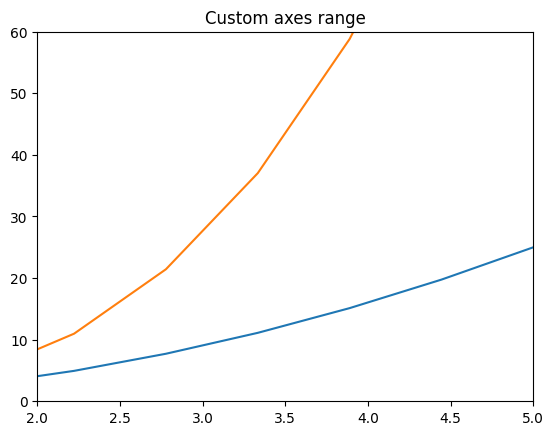

In [140]:
fig, ax = plt.subplots()

ax.plot(x, x**2, x, x**3) # note how you can also provide several x-y pairs
ax.set_xlim([2, 5])
ax.set_ylim([0, 60])
ax.set_title("Custom axes range")
plt.show()

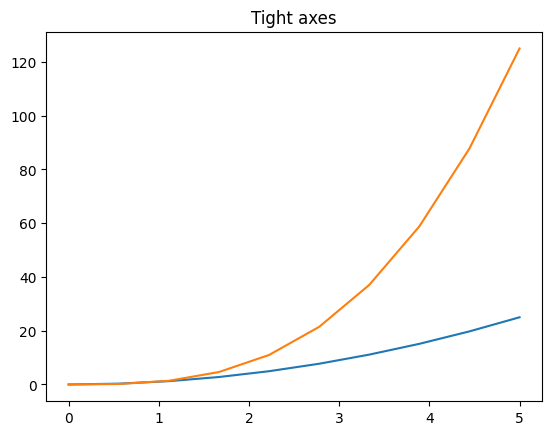

In [141]:
fig, ax = plt.subplots()

ax.plot(x, x**2, x, x**3) # note how you can also provide several x-y pairs
ax.axis("tight")
ax.set_title("Tight axes")
plt.show()

## Logarithmic scale

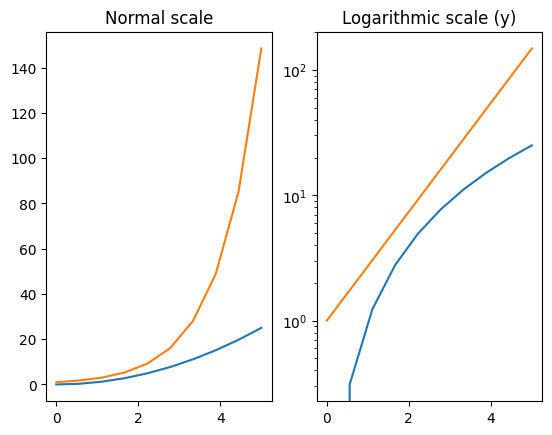

In [142]:
fig, axes = plt.subplots(1, 2)

axes[0].plot(x, x**2, x, np.exp(x))
axes[0].set_title("Normal scale")

axes[1].plot(x, x**2, x, np.exp(x))
axes[1].set_yscale("log")
axes[1].set_title("Logarithmic scale (y)")

plt.show()

## Placement of ticks and custom tick labels

We can explicitly determine where we want the axis ticks with `set_xticks` and `set_yticks`, which both take a list of values for where on the axis the ticks are to be placed. We can also use the `set_xticklabels` and `set_yticklabels` methods to provide a list of custom text labels for each tick location:

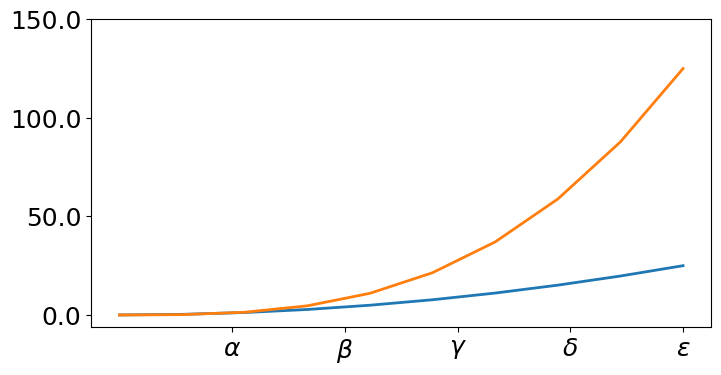

In [143]:
x = np.linspace(0, 5, 10)

xticks = [1, 2, 3, 4, 5]
custom_xticklabels = [r'$\alpha$', r'$\beta$', r'$\gamma$', r'$\delta$', r'$\epsilon$']

yticks = [0, 50, 100, 150]
custom_yticklabels = [f"{y:.1f}" for y in yticks]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, x**2, x, x**3, lw=2)
ax.set_xticks(xticks)
ax.set_xticklabels(custom_xticklabels, fontsize=18)
ax.set_yticks(yticks)
ax.set_yticklabels(custom_yticklabels, fontsize=18)

plt.show()

---

# Section 10: Figure Configuration and Export

**Description:** Figure size, DPI, saving in multiple formats

**Estimated Time:** 15-20 minutes

---


### From kopie
*Figure configuration and saving*


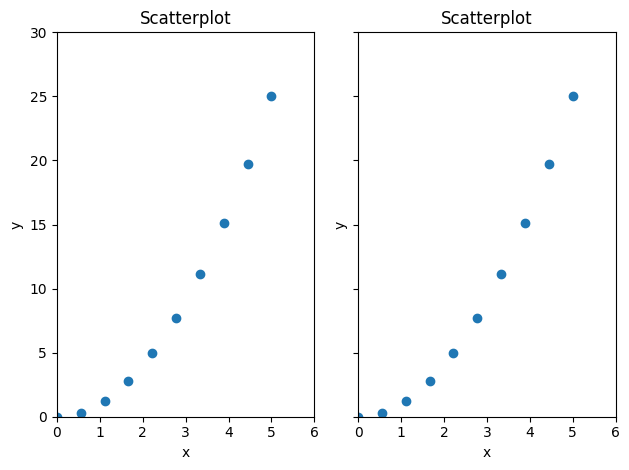

In [110]:
fig, axes = plt.subplots(1, 2, sharey=True)

for ax in axes:
    ax.plot(x, y, 'o')
    ax.set(title="Scatterplot", xlabel="x", ylabel="y",
           xlim=(0, 6), ylim=(0, 30))

fig.tight_layout()
plt.show()

## Figure size, aspect ratio and DPI

Matplotlib allows the aspect ratio, DPI and figure size to be specified when the `Figure` object is created, using the `figsize` and `dpi` keyword arguments. `figsize` is a tuple of the width and height of the figure in inches, and `dpi` is the dots-per-inch (pixel per inch). To create an 800x400 pixel, 100 dots-per-inch figure, we can do:

In [111]:
fig = plt.figure(figsize=(8, 4), dpi=100)

<Figure size 800x400 with 0 Axes>

The same arguments can also be passed to layout managers, such as the `subplots` function:

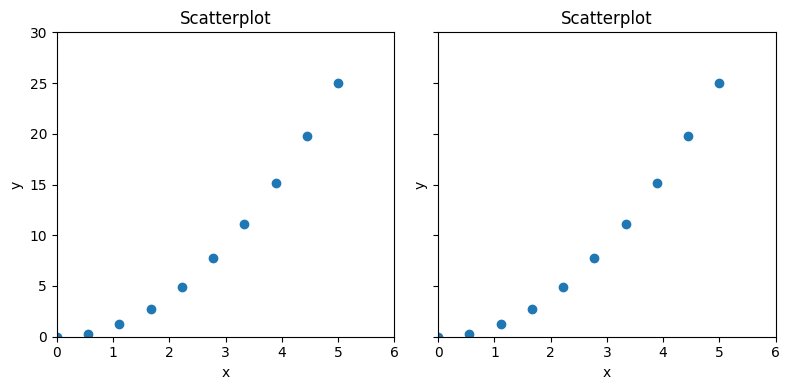

In [112]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(8, 4), dpi=100)

for ax in axes:
    ax.plot(x, y, 'o')
    ax.set(title="Scatterplot", xlabel="x", ylabel="y",
           xlim=(0, 6), ylim=(0, 30))

fig.tight_layout()
plt.show()

## Saving figures

To save a figure to a file we can use the `savefig` method in the `Figure` class:

In [113]:
fig.savefig("filename.png")

In this case, the image format is inferred from the filename extension. Available formats include PNG, JPG, EPS, SVG, PDF.

You can also specify the DPI and explicitly set an output format: note that, if you do specify a format, then the literal filename is used, regardless of its extension (it's up to you to check its consistency with the format).

In [114]:
fig.savefig("filename.png", dpi=200, format="png")

### From video
*Saving plots with figsave()*


In [ ]:
# Change the style... 
plt.style.use('seaborn-whitegrid')

---

# Section 11: Practical Integration & Best Practices

**Description:** Complete workflows, combining techniques, common pitfalls

**Estimated Time:** 20-25 minutes

---


### From fundamentals
*Practical growth curve example*


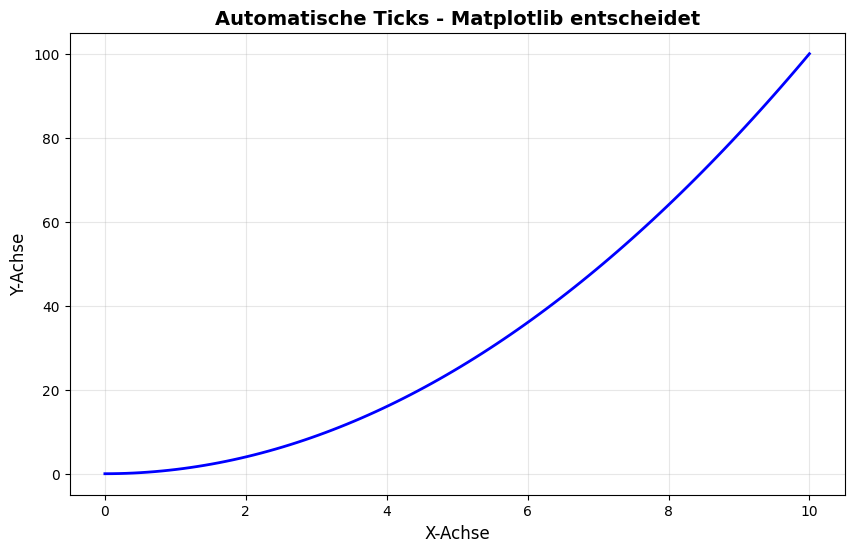

Automatisch gewählte Ticks:
X-Ticks: [-2.  0.  2.  4.  6.  8. 10. 12.]
Y-Ticks: [-20.   0.  20.  40.  60.  80. 100. 120.]

💡 Matplotlib wählt automatisch runde, sinnvolle Werte!


In [22]:
# Beispiel: Automatische Ticks

x = np.linspace(0, 10, 100)
y = x ** 2

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, y, 'b-', linewidth=2)
ax.set_title('Automatische Ticks - Matplotlib entscheidet', fontsize=14, weight='bold')
ax.set_xlabel('X-Achse', fontsize=12)
ax.set_ylabel('Y-Achse', fontsize=12)
ax.grid(True, alpha=0.3)

plt.show()

# Welche Ticks hat Matplotlib gewählt?
print("Automatisch gewählte Ticks:")
print(f"X-Ticks: {ax.get_xticks()}")
print(f"Y-Ticks: {ax.get_yticks()}")
print("\n💡 Matplotlib wählt automatisch runde, sinnvolle Werte!")

### From video
*OO method with pandas - advanced integration*


In [ ]:
# Doesn't work
car_sales.plot(x="Odometer (KM)", y="Price", kind="scatter")

ValueError: scatter requires y column to be numeric

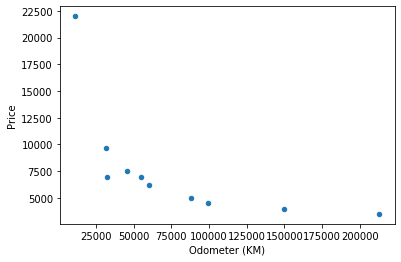

In [ ]:
# Convert Price to int
car_sales["Price"] = car_sales["Price"].astype(int)
car_sales.plot(x="Odometer (KM)", y="Price", kind='scatter');

### Bar
* Concept
* DataFrame

In [ ]:
x = np.random.rand(10, 4)
x

array([[0.91054912, 0.65668407, 0.75347508, 0.1488774 ],
       [0.4739657 , 0.65199569, 0.80087623, 0.25613654],
       [0.20515965, 0.14991211, 0.07454593, 0.15030318],
       [0.17102306, 0.97405707, 0.69580935, 0.41898253],
       [0.22654692, 0.1848998 , 0.01482526, 0.0647843 ],
       [0.54732069, 0.68484856, 0.71222659, 0.70537797],
       [0.50304196, 0.68331734, 0.0471555 , 0.94868537],
       [0.96833686, 0.19313494, 0.11765464, 0.13561539],
       [0.96998806, 0.50634506, 0.02096006, 0.32375073],
       [0.30732541, 0.10588319, 0.72021475, 0.07767541]])

In [ ]:
df = pd.DataFrame(x, columns=['a', 'b', 'c', 'd'])
df

,a,b,c,d
0,0.910549,0.656684,0.753475,0.148877
1,0.473966,0.651996,0.800876,0.256137
2,0.205160,0.149912,0.074546,0.150303
3,0.171023,0.974057,0.695809,0.418983
4,0.226547,0.184900,0.014825,0.064784
5,0.547321,0.684849,0.712227,0.705378
6,0.503042,0.683317,0.047155,0.948685
7,0.968337,0.193135,0.117655,0.135615
8,0.969988,0.506345,0.020960,0.323751
9,0.307325,0.105883,0.720215,0.077675


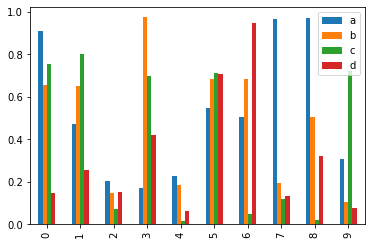

In [ ]:
df.plot.bar();

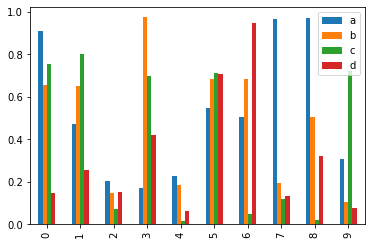

In [ ]:
# Can do the same thing with 'kind' keyword
df.plot(kind='bar');

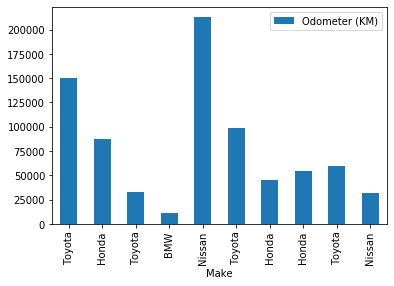

In [ ]:
car_sales.plot(x='Make', y='Odometer (KM)', kind='bar');

---

# Section 12: Self-Assessment & Next Steps

**Description:** Quiz questions, challenge exercises, and further resources

**Estimated Time:** 10-15 minutes

---


### From fundamentals
*Quiz section*


<!-- Translation needed from German -->

## Abschluss-Quiz: Hast du alles verstanden?

Beantworte diese Fragen für dich selbst:

1. **Warum `plt.show()` statt `fig.show()`?**
   - `plt.show()` ist die offizielle Methode, verwaltet alle Figures, schließt sie automatisch

2. **Was macht `np.linspace(0, 10, 50)`?**
   - Erstellt 50 gleichmäßig verteilte Punkte zwischen 0 und 10

3. **Was ist der Unterschied zwischen Figure und Axes?**
   - Figure = gesamtes Bild, Axes = Plot-Bereich mit Koordinatensystem

4. **Wie setzt Matplotlib die Achsengrenzen?**
   - Automatisch basierend auf Min/Max der Daten (mit Puffer)

5. **Warum NumPy Arrays statt Python-Listen?**
   - Vektorisierung, Performance, mathematische Funktionen

6. **Kann man `map()` auf NumPy Arrays verwenden?**
   - Ja, aber nicht empfohlen - nutze Vektorisierung stattdessen!

---

## Conclusion

Congratulations! You've completed the Matplotlib Complete Guide.

You now have a solid foundation in:
- Matplotlib's architecture and design philosophy
- Creating and customizing various plot types
- Working with both NumPy and Pandas data
- Professional plot styling and formatting
- Complex multi-panel figures
- Best practices for data visualization

### Next Steps

1. **Practice:** Apply these concepts to your own datasets
2. **Explore:** Check out matplotlib's gallery for inspiration
3. **Advanced Topics:** Consider learning about:
   - 3D plotting with mplot3d
   - Animations with matplotlib.animation
   - Interactive plots with widgets
   - Integration with other libraries (seaborn, plotly)

### Resources

- [Matplotlib Official Documentation](https://matplotlib.org/stable/contents.html)
- [Matplotlib Gallery](https://matplotlib.org/stable/gallery/index.html)
- [Matplotlib Cheat Sheets](https://matplotlib.org/cheatsheets/)
- [Python Graph Gallery](https://python-graph-gallery.com/)

**Happy Plotting! 📊📈📉**
